# Analyse des données énergétiques

Ce notebook contient l'analyse des données énergétiques normalisées et transformées.

## 0. Configuration et imports

In [43]:
import os
import sys
import json
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import probplot, fisher_exact, chi2_contingency, shapiro, t, normaltest, jarque_bera, anderson

from sklearn.model_selection import train_test_split, cross_val_predict, RepeatedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.utils import resample

import statsmodels.api as sm
from statsmodels.api import OLS, WLS, add_constant
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import outlier_test, OLSInfluence

import openai
from IPython.display import display, Markdown

import matplotlib.pyplot as plt

from dotenv import load_dotenv

import pprint


## 1. Chargement des données

In [44]:
root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root not in sys.path:
    sys.path.insert(0, root)

# 1) importer la fonction
from data_loader import load_data
# 2) Chargement des données
data = load_data()
data.head()


,f_relative_compactness,f_surface_area,f_wall_area,f_roof_area,f_overall_height,f_orientation,f_glazing_area,f_glazing_area_distribution,l_heating_load,l_cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## 2. Analyse des valeurs manquantes

In [45]:
def analyze_missing_values(df):
    """
    Analyse les valeurs manquantes dans un DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame à analyser
        
    Returns:
        dict: Dictionnaire contenant les statistiques des valeurs manquantes
    """
    # Calcul du nombre total de lignes
    total_rows = len(df)
    
    # Calcul des lignes avec au moins une valeur manquante
    rows_with_missing = df.isnull().any(axis=1).sum()
    
    # Calcul des statistiques par colonne
    missing_stats = df.isnull().sum()
    missing_percentages = (missing_stats / total_rows * 100).round(2)
    
    # Colonnes avec au moins une valeur manquante
    columns_with_missing = missing_stats[missing_stats > 0].index.tolist()
    
    return {
        'total_rows': total_rows,
        'rows_with_missing': rows_with_missing,
        'percentage_rows_with_missing': (rows_with_missing / total_rows * 100).round(2),
        'columns_with_missing': columns_with_missing,
        'missing_stats': pd.DataFrame({
            'missing_count': missing_stats,
            'missing_percentage': missing_percentages
        }).loc[columns_with_missing]
    }
    
def display_missing_values_analysis(df, title):
    """
    Affiche l'analyse des valeurs manquantes pour un ensemble de DataFrames.
    
    Args:
        data_dict (dict): Dictionnaire de DataFrames
        title (str): Titre de l'analyse
    """
    print(f"=== {title} === \n")
    
    missing_analysis = analyze_missing_values(df)
    
    print(f"Nombre total de lignes: {missing_analysis['total_rows']}")
    print(f"Lignes avec valeurs manquantes: {missing_analysis['rows_with_missing']} ({missing_analysis['percentage_rows_with_missing']}%)")
    
    if missing_analysis['columns_with_missing']:
        print("Colonnes avec valeurs manquantes:")
        print(missing_analysis['missing_stats'])
    else:
        print("Aucune valeur manquante dans ce fichier.")
    
    print("\n" + "="*50 + "\n")

In [46]:
# Analyse des données normalisées
display_missing_values_analysis(data, "Données normalisées")


=== Données normalisées === 

Nombre total de lignes: 768
Lignes avec valeurs manquantes: 0 (0.0%)
Aucune valeur manquante dans ce fichier.




## 3. Analyse des corrélations et sélection des variables

### 3.1 Matrice de corrélation des variables numériques

Analyse du fichier :
  Colonnes numériques trouvées: 8


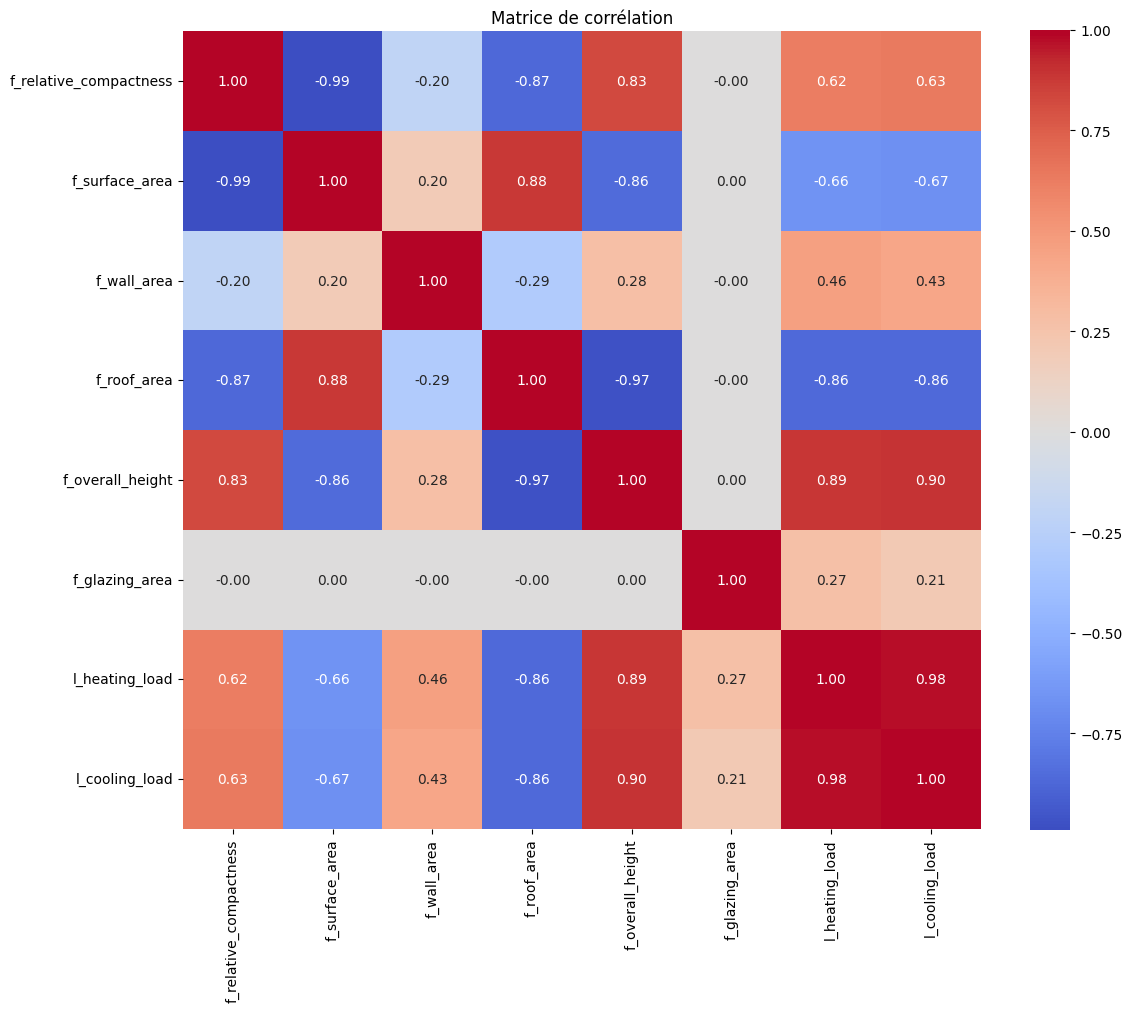

In [47]:
# Fonction pour créer la matrice de corrélation
def create_correlation_matrix(df):
    """
    Crée une matrice de corrélation pour chaque DataFrame dans le dictionnaire.
    
    Args:
        df: DataFrame
        
    Returns:
        dict: Dictionnaire contenant les matrices de corrélation
    """
    correlation_matrices = {}
    
    print(f"Analyse du fichier :")
    
    # Vérifier si le DataFrame est vide
    if df.empty:
        print(f"  Attention: Le DataFrame est vide!")
        return None        
    # Sélectionner uniquement les colonnes numériques
    numeric_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
    
    # Vérifier s'il y a des colonnes numériques
    if len(numeric_cols) == 0:
        print(f"  Attention: Aucune colonne numérique trouvée!")
        print("  Types de colonnes présents:", df.dtypes.unique())
        return None
        
    print(f"  Colonnes numériques trouvées: {len(numeric_cols)}")
    
    # Créer la matrice de corrélation
    corr_matrix = df[numeric_cols].corr()
    
    return corr_matrix

# Créer les matrices de corrélation pour les données normalisées converties
corr_matrix = create_correlation_matrix(data)

# Créer un heatmap sur la matrice de corrélation
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title(f'Matrice de corrélation')
plt.tight_layout()
plt.show()

### 3.2 Test d'indépendance des variables catégorielles

### Démarche d'analyse

Pour tester l'indépendance entre les features catégorielles (f_orientation et f_glazing_distribution), nous utilisons :

- **Test exact de Fisher** :
  * H0 : Les variables sont indépendantes
  * H1 : Il existe une dépendance entre les variables
  * Interprétation : Si p-value < 0.05, on rejette H0 et on conclut à une dépendance entre les variables


In [48]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact, chi2_contingency

def test_categorical_independence(df, var1, var2, alpha=0.05):
    """
    Teste l'indépendance entre deux variables catégorielles en choisissant :
      - Fisher exact si table 2×2
      - Sinon Chi² d'indépendance + Cramér's V

    Args:
        df (pd.DataFrame): DataFrame contenant les données
        var1 (str): Nom de la première variable catégorielle
        var2 (str): Nom de la deuxième variable catégorielle
        alpha (float): Seuil de signification (par défaut 0.05)
    """
    print(f"=== Indépendance entre {var1} et {var2} ===")
    # Table de contingence
    contingency = pd.crosstab(df[var1], df[var2])
    display(contingency)

    # Cas 2×2 → Fisher
    if contingency.shape == (2, 2):
        odds_ratio, p_value = fisher_exact(contingency)
        print(f"Test exact de Fisher : p-value = {p_value:.4f}, odds ratio = {odds_ratio:.2f}")
        interpr = "→ dépendance" if p_value < alpha else "→ indépendance"
        print(f"Interprétation (α={alpha}): {interpr}")
        return

    # Sinon → Chi²
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"Chi² = {chi2:.2f}, ddl = {dof}, p-value = {p:.4f}")

    # Vérifier les effectifs attendus
    low_exp = (expected < 5).sum()
    total = expected.size
    if low_exp / total > 0.2:
        print(f"⚠️ {low_exp}/{total} cases ont un effectif attendu <5 → conditions du Chi² non respectées")

    # Taille d'effet : Cramér's V
    n = contingency.values.sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    print(f"Cramér’s V = {cramers_v:.3f}")

    interpr = "→ dépendance" if p < alpha else "→ indépendance"
    print(f"Interprétation (α={alpha}): {interpr}")

# Application à tes DataFrames
print("="*80)
cats = [c for c in data.columns 
        if data[c].dtype.name == 'category' and c.startswith('f_')]
for i in range(len(cats)):
    for j in range(i+1, len(cats)):
        test_categorical_independence(data, cats[i], cats[j])

=== Indépendance entre f_orientation et f_glazing_area_distribution ===


f_glazing_area_distribution,0,1,2,3,4,5
f_orientation,,,,,,
2,12,36,36,36,36,36
3,12,36,36,36,36,36
4,12,36,36,36,36,36
5,12,36,36,36,36,36


Chi² = 0.00, ddl = 15, p-value = 1.0000
Cramér’s V = 0.000
Interprétation (α=0.05): → indépendance


### 3.3 Sélection des features

### Démarche d'analyse
Nous allons appliquer l'algorithme de sélection des features en trois étapes :

1. **Sélection initiale des features numériques** :
   - Calcul de la somme des corrélations absolues avec tous les labels pour chaque feature
   - Tri des features par ordre décroissant de cette somme (les plus corrélées d'abord)
   - Sélection itérative en évitant la multicolinéarité :
     * On prend la première feature (la plus corrélée avec les labels)
     * Pour chaque feature restante, on la garde uniquement si sa corrélation avec toutes les features déjà sélectionnées est ≤ 0.85
     * Cela permet d'éviter la redondance d'information tout en gardant les features les plus pertinentes

2. **Sélection des features catégorielles** :
   - Calcul d'un score de "corrélation" pour chaque feature catégorielle :
     * Pour chaque label, on effectue un test statistique (Wilcoxon ou Kruskal-Wallis selon le nombre de classes)
     * Le score est la somme des -log(p-value) pour tous les labels
     * Plus le score est élevé, plus la feature est liée aux labels
   - Tri des features par score décroissant
   - Élimination des redondances :
     * Test de Fisher entre chaque paire de features catégorielles
     * Si dépendance détectée (p-value < 0.05), on garde celle avec le meilleur score

3. **Validation finale** :
   - Pour chaque paire (feature numérique, feature catégorielle) :
     * Test statistique (Kruskal si plus de 2 modalités) pour vérifier leur indépendance
     * Si dépendance détectée (p-value < 0.05), on élimine la feature catégorielle
     * Cela permet d'éviter la redondance entre types de features différents


In [49]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact

# Initialiser les ensembles pour stocker les features
features_to_keep = set()
features_to_eliminate = set()

print(f"{'='*80}")

# Identifier les features numériques et catégorielles
numeric_features = [col for col in data.columns 
                    if col.startswith('f_') and data[col].dtype in ['int64', 'float64']]
categorical_features = [col for col in data.columns 
                        if col.startswith('f_') and data[col].dtype.name == 'category']
labels = [col for col in data.columns if col.startswith('l_')]

# 1. Sélection des features numériques (inchangé)
corr_sums = {feature: sum(abs(data[feature].corr(data[label])) for label in labels)
             for feature in numeric_features}
sorted_features = sorted(corr_sums.items(), key=lambda x: x[1], reverse=True)
selected_numeric = []
for feature, _ in sorted_features:
    if not selected_numeric:
        selected_numeric.append(feature)
    else:
        if all(abs(data[feature].corr(data[f])) <= 0.85 for f in selected_numeric):
            selected_numeric.append(feature)
print("Features numériques sélectionnées:", selected_numeric)

# 2. Sélection des features catégorielles
#    calcul de score (Wilcoxon ou Kruskal) inchangé
categorical_scores = {}
for feature in categorical_features:
    total_score = 0
    for label in labels:
        groups = [g[label].values for _, g in data.groupby(feature, observed=False)]
        if len(groups) == 2:
            _, p = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        else:
            _, p = stats.kruskal(*groups)
        total_score += -np.log(p) if p > 0 else 1000
    categorical_scores[feature] = total_score

sorted_categorical = [f for f, _ in sorted(categorical_scores.items(), key=lambda x: x[1], reverse=True)]
to_eliminate = set()

# Boucle d'élimination basée sur dépendance entre paires
for i in range(len(sorted_categorical)):
    f1 = sorted_categorical[i]
    if f1 in to_eliminate:
        continue
    for f2 in sorted_categorical[i+1:]:
        if f2 in to_eliminate:
            continue

        # 2×2 ? Fisher : sinon Chi²
        contingency = pd.crosstab(data[f1], data[f2])
        if contingency.shape == (2, 2):
            _, p_val = fisher_exact(contingency)
        else:
            _, p_val, _, _ = chi2_contingency(contingency)

        if p_val < 0.05:
            # on élimine la moins « informative »
            if categorical_scores[f1] >= categorical_scores[f2]:
                to_eliminate.add(f2)
            else:
                to_eliminate.add(f1)
                break

selected_categorical = [f for f in sorted_categorical if f not in to_eliminate]
print("Features catégorielles sélectionnées:", selected_categorical)

# 3. Dernière passe : dépendance catégorielle vs numérique
categorical_to_eliminate = set()
for cat in selected_categorical:
    for num in selected_numeric:
        groups = [g[num].values for _, g in data.groupby(cat, observed=False)]
        if len(groups) == 2:
            _, p = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        else:
            _, p = stats.kruskal(*groups)
        if p < 0.05:
            categorical_to_eliminate.add(cat)
            break

final_categorical = [f for f in selected_categorical if f not in categorical_to_eliminate]

# Mise à jour des ensembles globaux
features_to_keep.update(selected_numeric + final_categorical)
features_to_eliminate.update(
    [f for f in numeric_features if f not in selected_numeric] +
    [f for f in categorical_features if f not in final_categorical]
)

# Résumé
print("\nRésultats finaux:")
print(" → Conservées :", selected_numeric + final_categorical)
print(" → Éliminées :", sorted(to_eliminate | categorical_to_eliminate))

# Affichage d’un tableau récapitulatif
summary = []
for feat in numeric_features + categorical_features:
    status = "Conservée" if feat in features_to_keep else "Éliminée"
    if feat in selected_numeric:
        reason = "Corrélation élevée avec labels"
    elif feat in final_categorical:
        reason = "Score élevé et indépendance validée"
    elif feat in to_eliminate:
        reason = "Dépendance entre catégorielles"
    elif feat in categorical_to_eliminate:
        reason = "Dépendance avec numérique"
    else:
        reason = "Score insuffisant"
    summary.append({
        'Feature': feat,
        'Type': 'Numérique' if feat in numeric_features else 'Catégorielle',
        'Status': status,
        'Raison': reason
    })
summary_df = pd.DataFrame(summary)
display(
    summary_df.style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left')]},
            {'selector': 'td', 'props': [('text-align', 'left')]}
        ])
        .hide(axis='index')
)

# Enfin, construire le dictionnaire filtré
cols_to_drop = [f for f in data.columns if f in features_to_eliminate]
data_selected = data.drop(columns=cols_to_drop)


Features numériques sélectionnées: ['f_overall_height', 'f_relative_compactness', 'f_wall_area', 'f_glazing_area']
Features catégorielles sélectionnées: ['f_glazing_area_distribution', 'f_orientation']

Résultats finaux:
 → Conservées : ['f_overall_height', 'f_relative_compactness', 'f_wall_area', 'f_glazing_area', 'f_orientation']
 → Éliminées : ['f_glazing_area_distribution']


Feature,Type,Status,Raison
f_relative_compactness,Numérique,Conservée,Corrélation élevée avec labels
f_surface_area,Numérique,Éliminée,Score insuffisant
f_wall_area,Numérique,Conservée,Corrélation élevée avec labels
f_roof_area,Numérique,Éliminée,Score insuffisant
f_overall_height,Numérique,Conservée,Corrélation élevée avec labels
f_glazing_area,Numérique,Conservée,Corrélation élevée avec labels
f_orientation,Catégorielle,Conservée,Score élevé et indépendance validée
f_glazing_area_distribution,Catégorielle,Éliminée,Dépendance avec numérique


## 4. Opérations de transformation

### 4.1 Définition des transformations examinées

In [50]:
# vos autres transform et inverse-transform
TRANSFORM_FNS = {
    'none':   lambda x: x,
    'log':    np.log,
    'log1p':  np.log1p,
    'sqrt':   np.sqrt,
    'cbrt':   np.cbrt,
    'square': lambda x: x**2,
    'cube':   lambda x: x**3,
    'power4': lambda x: x**4,
}

INV_TRANSFORM_FNS = {
    'none':   lambda x: x,
    'log':    np.exp,
    'log1p':  np.expm1,
    'sqrt':   lambda x: x**2,
    'cbrt':   lambda x: x**3,
    'square': np.sqrt,
    'cube':   np.cbrt,
    'power4': lambda x: x**(1/4),
}

def apply_transform(series: pd.Series, method: str):
    """
    Retourne serie_t pour les autres méthodes
    """
    fn = TRANSFORM_FNS.get(method)
    if fn is None:
        raise ValueError(f"Transformation inconnue: {method}")
    return fn(series.values)

def inverse_transform(y, method: str):
    """
    Applique l'inverse de la transformation.
    """
    fn = INV_TRANSFORM_FNS.get(method)
    if fn is None:
        raise ValueError(f"Transformation inverse inconnue: {method}")
    return fn(y)

#l_transformations représente la liste des transformations analysées pour les labels
l_transformations = ['log', 'sqrt', 'square', 'cube', 'power4', 'cbrt']
#f_transformations = ['log', 'sqrt', 'square']

#f_transformations représente la liste des transformations analysées pour les features
f_transformations = ['log', 'sqrt', 'square']#OK
#f_transformations = ['log', 'sqrt', 'square', 'cube', 'power4', 'cbrt']
#f_transformations = ['log', 'sqrt', 'square', 'cube', 'cbrt']
#f_transformations = ['log', 'sqrt', 'square', 'cube']
#f_transformations = ['log', 'sqrt', 'square', 'cbrt']
#f_transformations = ['log', 'sqrt', 'square', 'power4']
#f_transformations = ['log', 'sqrt', 'power4']
#f_transformations = ['log', 'sqrt', 'cube']
#f_transformations = ['sqrt','square', 'cube']
#f_transformations = ['log','square', 'cube']
#l_transformations = ['log', 'sqrt', 'square']


### 4.2 Analyse des distributions des labels

### Objectif
Analyser la distribution des variables cibles (labels) pour identifier des transformations potentielles qui pourraient améliorer leur adéquation avec un modèle linéaire.

Pour chaque label, nous allons :
1. Visualiser sa distribution avec un histogramme et une courbe de densité
2. Calculer les statistiques descriptives (moyenne, médiane, écart-type, skewness, kurtosis)
3. Tester différentes transformations (log, racine carrée, carré, cube)
4. Visualiser les distributions transformées
5. Calculer les statistiques des distributions transformées
6. Recommander les transformations les plus pertinentes


In [51]:
def analyze_distribution(df: pd.DataFrame, column: str, l_transformations: list):
    print(f"--- Analyse de '{column}' ---")
    data = df[column].dropna()
    # stats de base
    print(data.agg(['mean','median','std','skew','kurtosis']))
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes_list = [axes[i,j] for i in range(3) for j in range(3) if not (i==2 and j==2)]
    
    for ax, method in zip(axes_list, l_transformations):
        try:
            series_t = apply_transform(data, method)
            title = method.capitalize()
        except Exception as e:
            print(f"⚠ Erreur sur '{method}': {e}")
            # on continue sans masquer l'axe, pour avoir le titre en rouge
            ax.set_title(f"{method} : ERREUR")
            ax.text(0.5, 0.5, str(e),
                    ha='center', va='center', transform=ax.transAxes,
                    color='red', wrap=True)
            continue
        
        ax.hist(series_t, bins=30, edgecolor='black')
        ax.set_title(title)
        stats_t = pd.Series(series_t).agg(['skew','kurtosis'])
        ax.text(0.95, 0.95,
                f"Skew: {stats_t['skew']:.2f}\nKurt: {stats_t['kurtosis']:.2f}",
                transform=ax.transAxes, ha='right', va='top')
    
    # QQ-plot
    ax_qq = axes[2,2]
    probplot(data, dist='norm', plot=ax_qq)
    ax_qq.set_title('QQ-plot (original)')
    
    plt.tight_layout(rect=[0,0.03,1,0.95])
    plt.show()


Analyse des distributions

Analyse de la distribution de l_heating_load
--- Analyse de 'l_heating_load' ---
mean        22.307195
median      18.950000
std         10.090204
skew         0.360446
kurtosis    -1.245569
Name: l_heating_load, dtype: float64


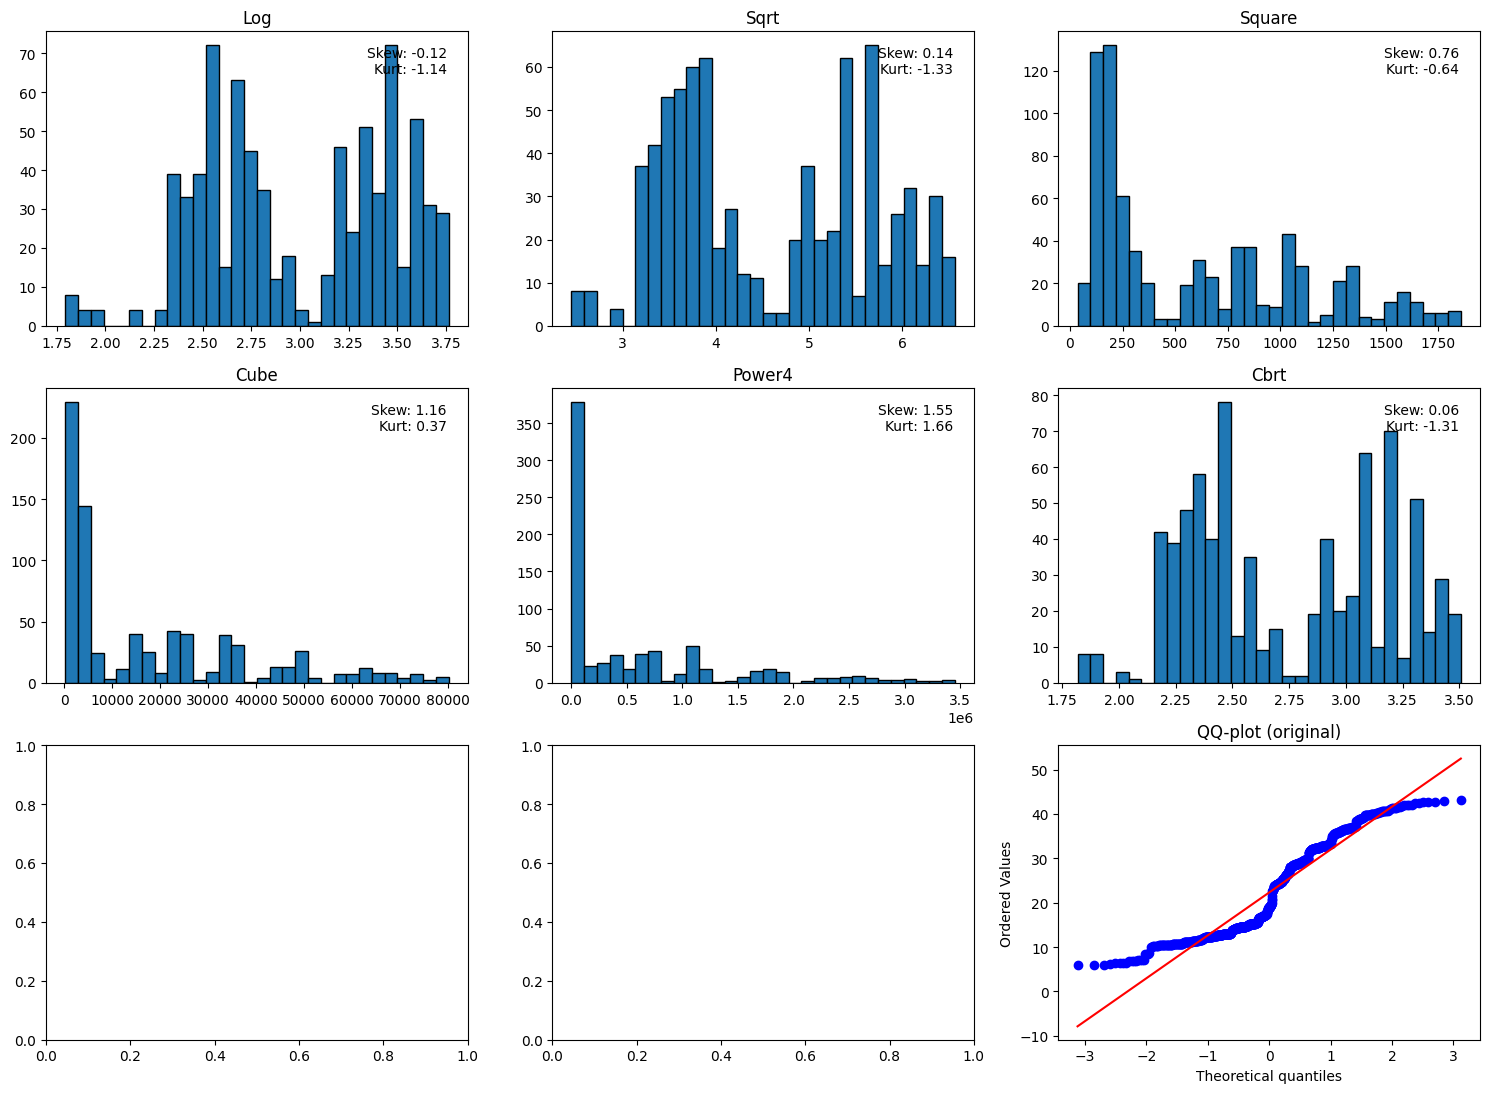


Analyse de la distribution de l_cooling_load
--- Analyse de 'l_cooling_load' ---
mean        24.587760
median      22.080000
std          9.513306
skew         0.395992
kurtosis    -1.147190
Name: l_cooling_load, dtype: float64


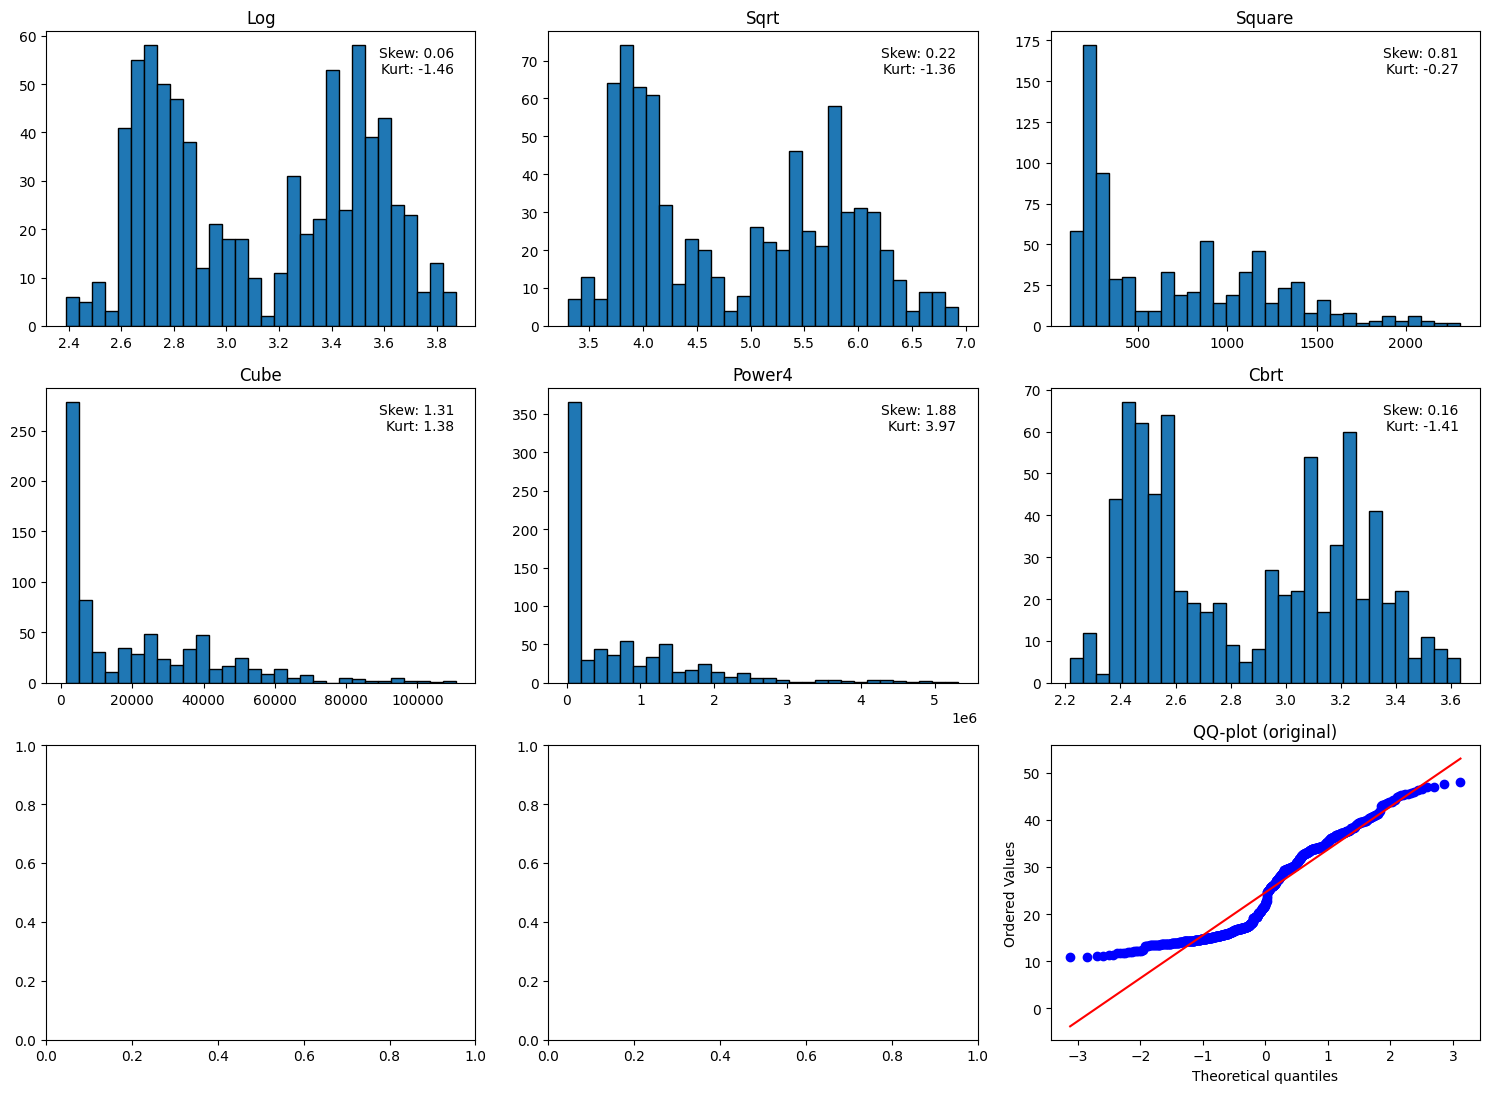

In [52]:
# Analyse des distributions pour chaque label
print(f"\nAnalyse des distributions")
for label in labels:
    print(f"\nAnalyse de la distribution de {label}")
    analyze_distribution(data_selected, label,l_transformations)


### 4.3 Analyse GPT des distributions

### Objectif
Utiliser un modèle GPT pour analyser les résultats des transformations et recommander la transformation la plus appropriée pour chaque label dans le cadre d'un modèle linéaire.


In [53]:
def analyze_distributions_with_gpt(
    df: pd.DataFrame,
    labels: list,
    l_transformations: list
) -> list:
    """
    Pour chaque label de df, calcule skew/kurt avant et après transformations,
    """
    load_dotenv()
    if not os.getenv("OPENAI_API_KEY"):
        raise RuntimeError("La clé OPENAI_API_KEY n'est pas définie.")
    openai.api_key = os.getenv("OPENAI_API_KEY")
    
    # 1) Construire label_stats
    label_stats = {}
    for label in labels:
        series = df[label].dropna()
        orig_skew = float(series.skew())
        orig_kurt = float(series.kurtosis())
        
        trans_stats = {}
        for method in l_transformations:
            data_t = apply_transform(series, method)
            
            s = pd.Series(data_t)
            trans_stats[method] = {
                "skewness": float(s.skew()),
                "kurtosis": float(s.kurtosis())
            }
        
        label_stats[label] = {
            "original": {"skewness": orig_skew, "kurtosis": orig_kurt},
            "transformations": trans_stats
        }
    
    # 2) Pour chaque label, on appelle l'API
    recommendations = []
    for label, stats in label_stats.items():
        # Construire le prompt_str
        prompt_str = (
            f"Analyse la distribution de la variable **{label}**"
            f"et recommande la meilleure transformation pour un modèle linéaire.\n\n"
            f"Statistiques originales :\n"
            f"- Skewness : {stats['original']['skewness']:.2f}\n"
            f"- Kurtosis : {stats['original']['kurtosis']:.2f}\n\n"
            "Statistiques après transformations :\n"
        )
        for method, tstats in stats["transformations"].items():
            prompt_str += (
                f"- {method} : skewness={tstats['skewness']:.2f}, "
                f"kurtosis={tstats['kurtosis']:.2f}\n"
            )
        prompt_str += (
            "\nRecommandation :\n"
            "1. Identifie la transformation qui donne la distribution la plus proche d'une loi normale.\n"
            "2. Justifie ton choix à partir des mesures de skewness et kurtosis.\n"
            "3. Répond au format JSON :\n"
            "{\n"
            '  "label": "nom_du_label",\n'
            '  "transformation": "nom_de_la_transformation_recommandée",\n'
            '  "justification": "…"\n'
            "}\n"
        )

        messages = [
            {"role": "system", "content": "Tu es un expert en analyse de données et en statistiques."},
            {"role": "user",   "content": prompt_str}
        ]

        try:
            resp = openai.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=messages,
                temperature=0.7
            )
            #print(messages)
            text = resp.choices[0].message.content
            # Extraction robuste du JSON
            start = text.find("{")
            end = text.rfind("}") + 1
            rec = json.loads(text[start:end])
        except Exception as e:
            print(f"⚠ Erreur GPT pour '{label}': {e}")
            rec = {
                "label": label,
                "transformation": "none",
                "justification": f"Erreur GPT ou parsing : {e}"
            }
        if rec["transformation"].lower() not in l_transformations:
            rec = {
                "label": label,
                "transformation": "none",
                "justification": f"Transformation non prise en compte"
            }

        recommendations.append(rec)

    return recommendations

In [54]:
gpt_results = None
features_to_eliminate = set()

print("=" * 80)
print(f"Analyse GPT des distributions")

labels = [c for c in data_selected.columns if c.startswith("l_")]

gpt_results = analyze_distributions_with_gpt(
    df=data_selected,
    labels=labels,
    l_transformations=l_transformations
)

print("Résultats de l'analyse GPT :")
for r in gpt_results:
    print(f"Analyse pour {r['label']}:")
    print(f"  Transformation recommandée : {r['transformation']}")
    print(f"  Justification : {r['justification']}")
    print("-" * 40)
    if r["transformation"].lower() == "none":
        features_to_eliminate.add(r["label"])


Analyse GPT des distributions
Résultats de l'analyse GPT :
Analyse pour l_heating_load:
  Transformation recommandée : log
  Justification : La transformation log a réduit à la fois la skewness et la kurtosis, se rapprochant ainsi d'une distribution normale. La skewness est très proche de 0 et la kurtosis est plus proche de -1, ce qui indique une meilleure symétrie des données et une queue moins lourde, respectivement.
----------------------------------------
Analyse pour l_cooling_load:
  Transformation recommandée : log
  Justification : La transformation log donne la distribution la plus proche d'une loi normale avec une skewness proche de zéro et une kurtosis plus proche de celle d'une distribution normale que les autres transformations. Cela indique que la distribution des données après transformation log est plus symétrique et moins influencée par les valeurs extrêmes, ce qui est souhaitable pour un modèle linéaire.
----------------------------------------


### 4.4. Transformation des labels et visualisation

### Objectif
Transformer les labels selon les recommandations de GPT et visualiser l'impact des transformations sur les relations avec les features conservées uniquement.


Transformation des labels
Transformation de l_heating_load avec log :
  Avant  – Skewness: 0.36, Kurtosis: -1.25
  Après  – Skewness: -0.12, Kurtosis: -1.14
Transformation de l_cooling_load avec log :
  Avant  – Skewness: 0.40, Kurtosis: -1.15
  Après  – Skewness: 0.06, Kurtosis: -1.46
Graphiques pour l_heating_load :


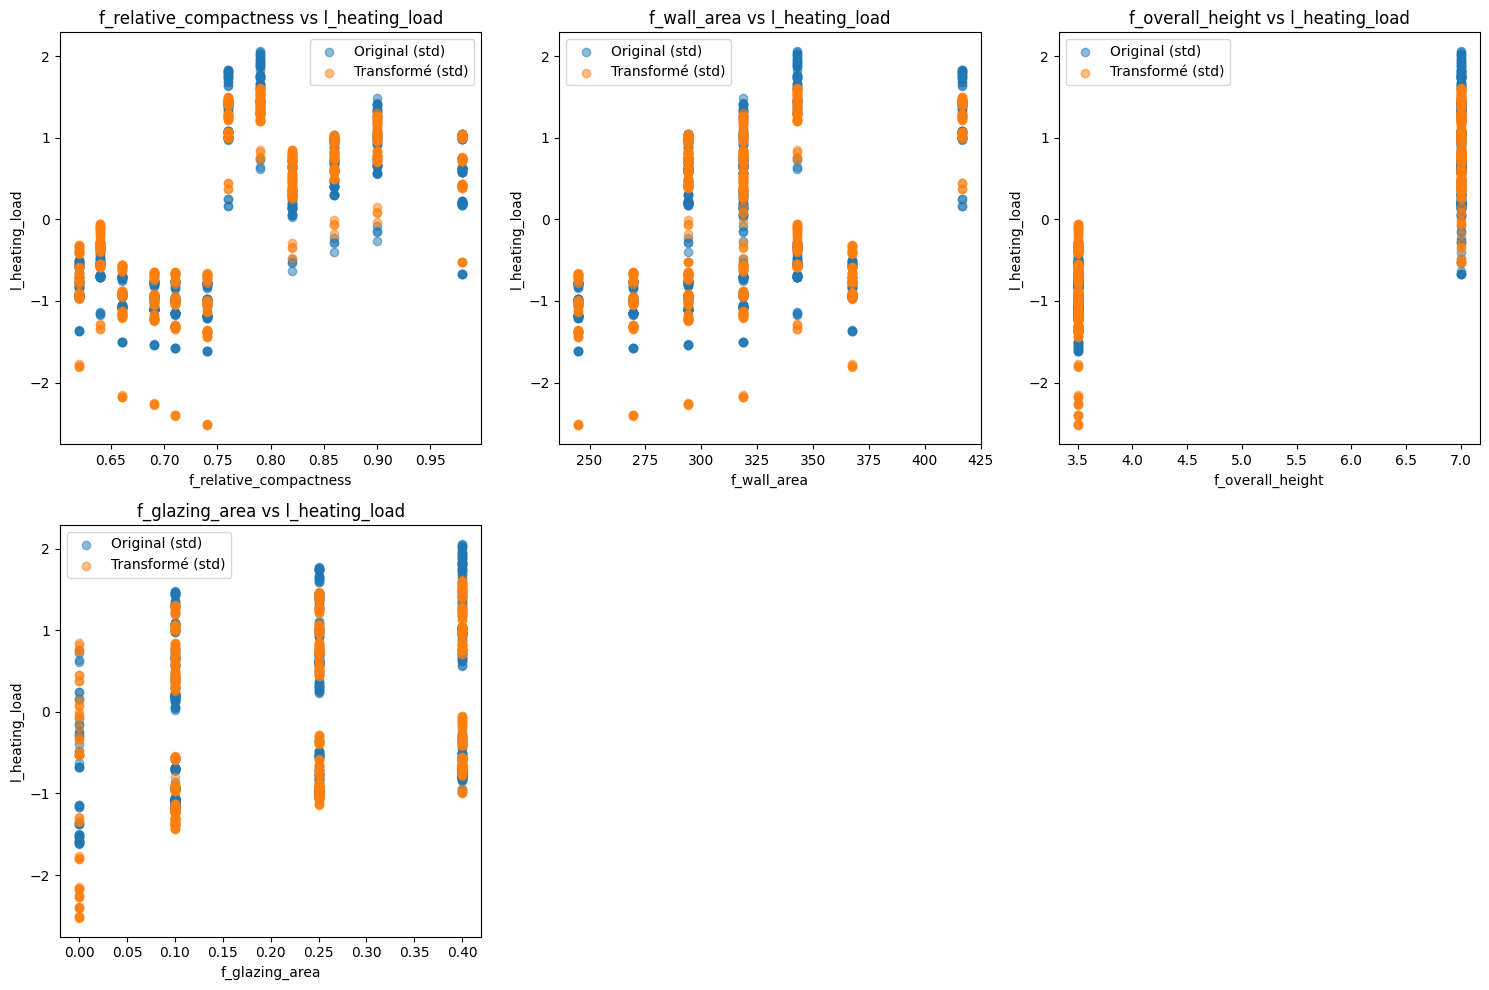

Matrices de corrélation :


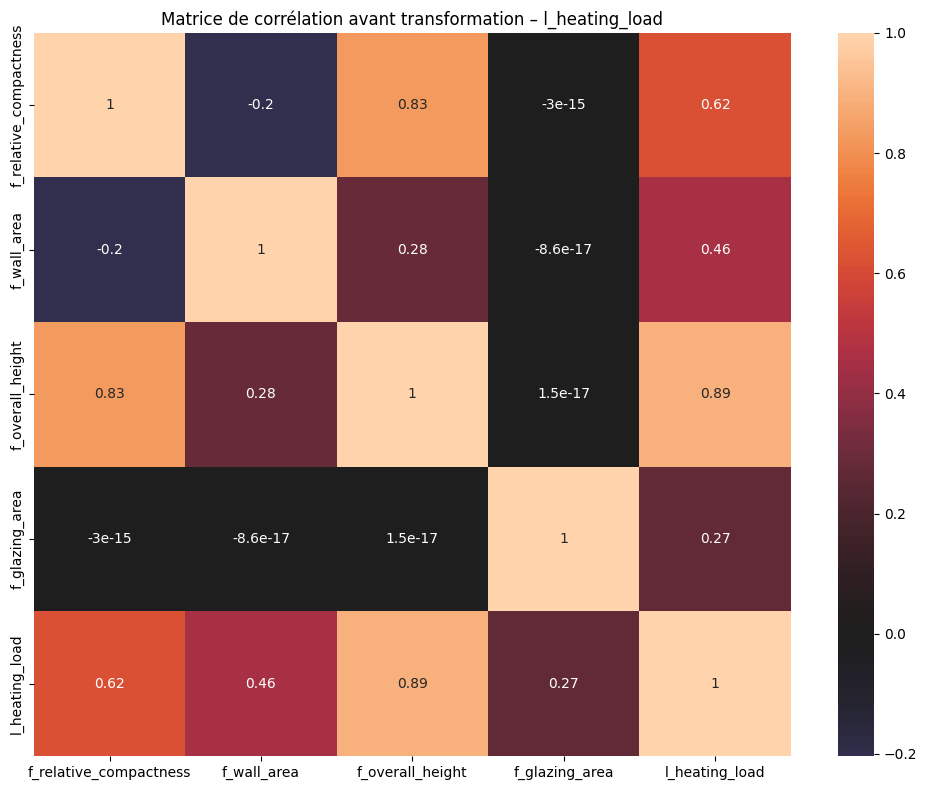

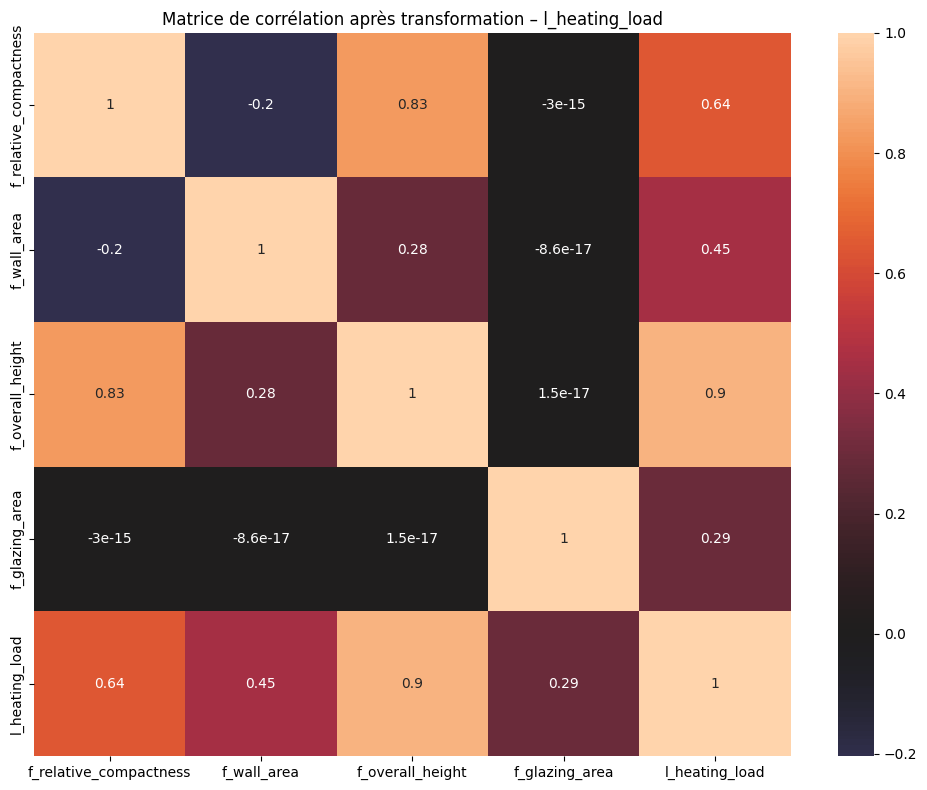

Graphiques pour l_cooling_load :


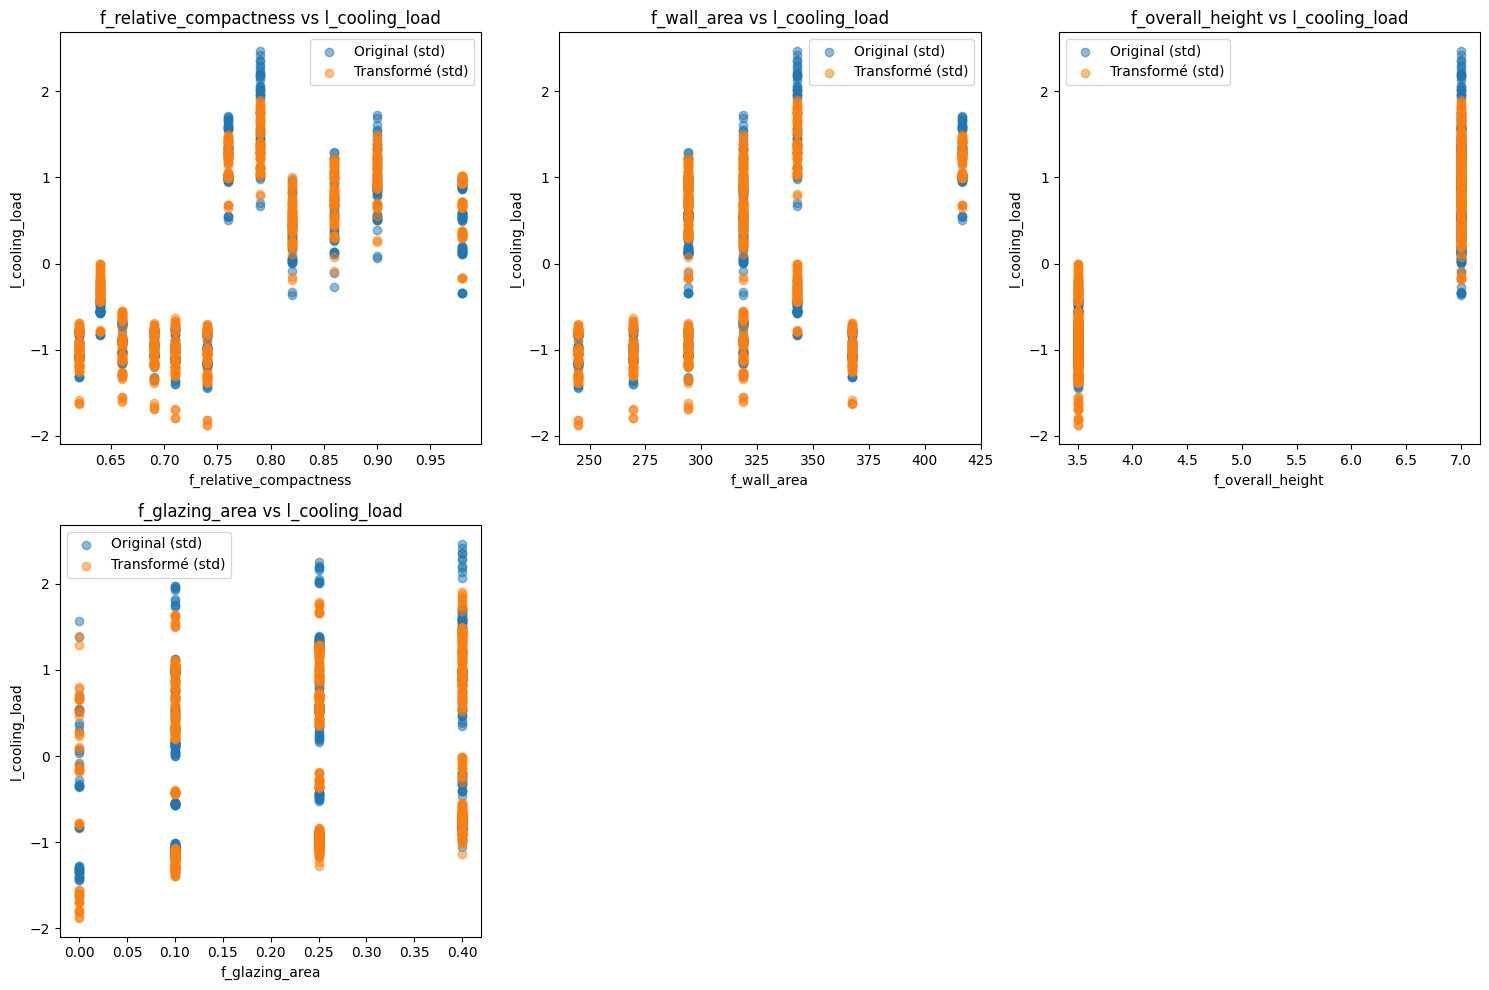

Matrices de corrélation :


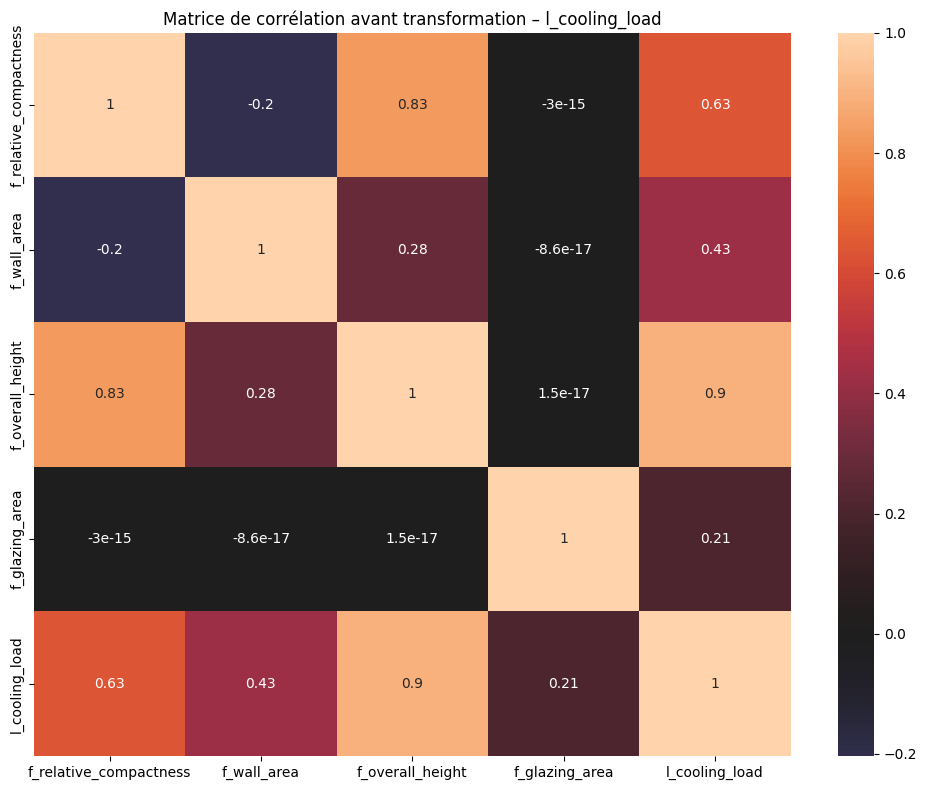

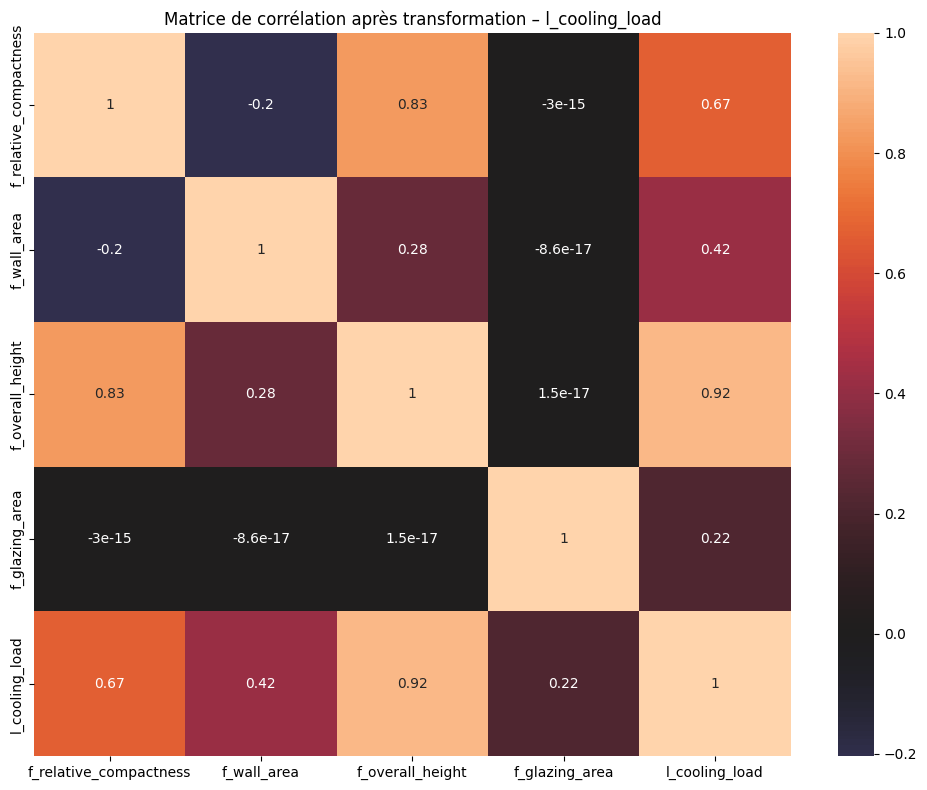

In [55]:
# Transformer les labels selon les recommandations de GPT
df_selected_copy = data_selected.copy()
df_transformed = data_selected.copy()

print("=" * 80)
print(f"Transformation des labels")

for rec in gpt_results:
    label = rec["label"]
    method = rec["transformation"].lower()

    if method == "none":
        continue

    print(f"Transformation de {label} avec {method} :")
    try:
        series_t = apply_transform(df_selected_copy[label], method)

        # On remplace la colonne transformée
        df_transformed[label+"_orig"] = df_transformed[label]
        df_transformed[label] = series_t
        
        # Affichage des stats avant / après
        orig_skew, orig_kurt = df_selected_copy[label].skew(), df_selected_copy[label].kurtosis()
        new_skew, new_kurt = df_transformed[label].skew(), df_transformed[label].kurtosis()
        print(f"  Avant  – Skewness: {orig_skew:.2f}, Kurtosis: {orig_kurt:.2f}")
        print(f"  Après  – Skewness: {new_skew:.2f}, Kurtosis: {new_kurt:.2f}")

    except Exception as e:
        print(f"⚠ Erreur pendant la transformation {method} de {label} : {e}")

# Sélection des features et labels
features = [c for c in df_selected_copy.columns if c.startswith("f_") and c in features_to_keep and pd.api.types.is_numeric_dtype(df_selected_copy[c])]
labels = [c for c in df_selected_copy.columns if c.startswith("l_") and not(c.endswith("_orig"))]

for label in labels:
    print(f"Graphiques pour {label} :")
    #On va centrer/réduire les labels pour que ce soit comparable.
    scaler = StandardScaler()
    y_orig_std      = scaler.fit_transform(df_selected_copy[[label]])
    y_transf_std    = scaler.fit_transform(df_transformed[[label]])
    
    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        ax = axes[i]
        # Original vs Transformé
        ax.scatter(df_selected_copy[feature], y_orig_std, alpha=0.5, label="Original (std)")
        ax.scatter(df_selected_copy[feature], y_transf_std, alpha=0.5, label="Transformé (std)")
        ax.set_xlabel(feature)
        ax.set_ylabel(label)
        ax.set_title(f"{feature} vs {label}")
        ax.legend()

    # Masquer les axes restants
    for j in range(len(features), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Matrices de corrélation avant et après
    print("Matrices de corrélation :")

    corr_before = df_selected_copy[features + [label]].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_before, annot=True, center=0)
    plt.title(f"Matrice de corrélation avant transformation – {label}")
    plt.tight_layout()
    plt.show()

    corr_after = df_transformed[features + [label]].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_after, annot=True, center=0)
    plt.title(f"Matrice de corrélation après transformation – {label}")
    plt.tight_layout()
    plt.show()

### 4.5 Création de features polynomiales pour les relations non-linéaires

### Objectif
Pour chaque feature qui présente une relation non-linéaire avec un des labels, créer des transformations polynomiales :
- log
- racine carrée
- racine cubique
- carré
- cube
- puissance 4

Ces nouvelles features seront utilisées dans la sélection de modèles qui suit.

### Critère de non-linéarité
Une feature est considérée comme ayant une relation non-linéaire potentielle avec le label si sa corrélation est modérée, c'est-à-dire entre 0.33 et 0.66 (en valeur absolue).


Création des features polynomiales

Analyse pour le label l_heating_load :
Features sélectionnées : ['f_relative_compactness', 'f_wall_area']
– 6 nouvelles colonnes créées
Exemple (5 premières) :


,f_relative_compactness_log,f_relative_compactness_sqrt,f_relative_compactness_square,f_wall_area_log,f_wall_area_sqrt
0,-0.020203,0.989949,0.9604,5.683580,17.146428
1,-0.020203,0.989949,0.9604,5.683580,17.146428
2,-0.020203,0.989949,0.9604,5.683580,17.146428
3,-0.020203,0.989949,0.9604,5.683580,17.146428
4,-0.105361,0.948683,0.8100,5.763622,17.846568


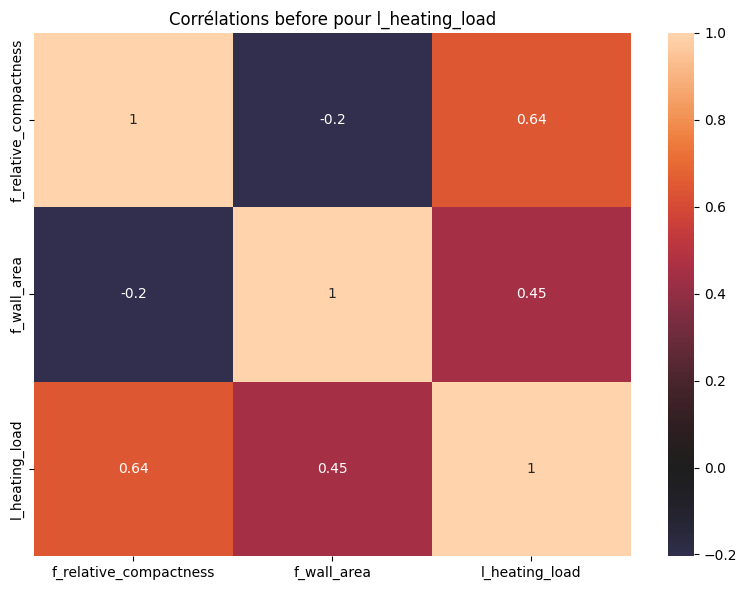

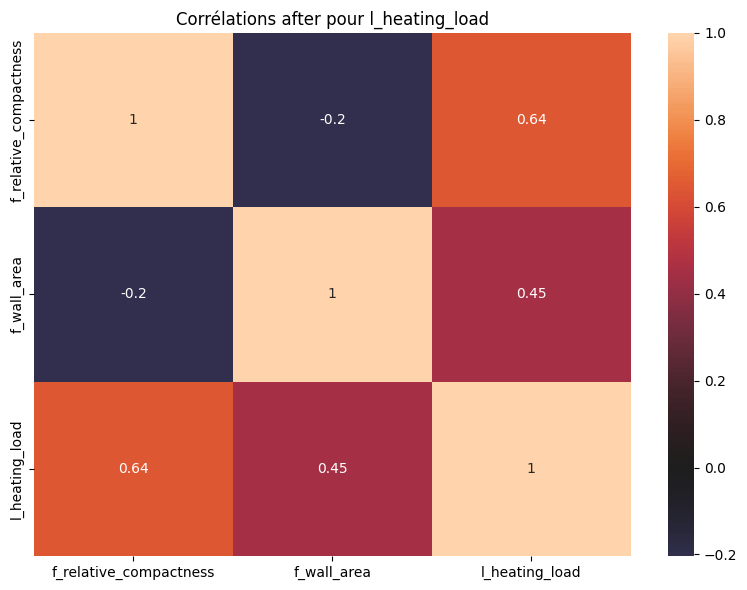


Analyse pour le label l_cooling_load :
Features sélectionnées : ['f_relative_compactness', 'f_wall_area']
– 6 nouvelles colonnes créées
Exemple (5 premières) :


,f_relative_compactness_log,f_relative_compactness_sqrt,f_relative_compactness_square,f_wall_area_log,f_wall_area_sqrt
0,-0.020203,0.989949,0.9604,5.683580,17.146428
1,-0.020203,0.989949,0.9604,5.683580,17.146428
2,-0.020203,0.989949,0.9604,5.683580,17.146428
3,-0.020203,0.989949,0.9604,5.683580,17.146428
4,-0.105361,0.948683,0.8100,5.763622,17.846568


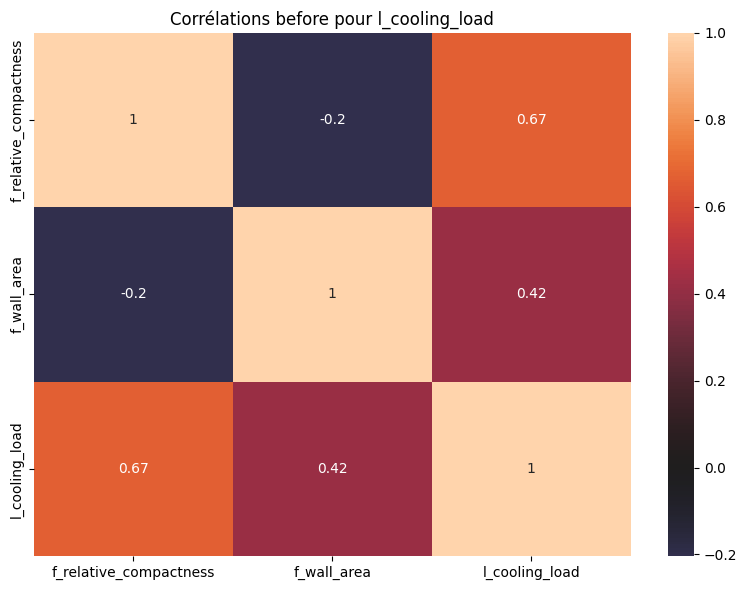

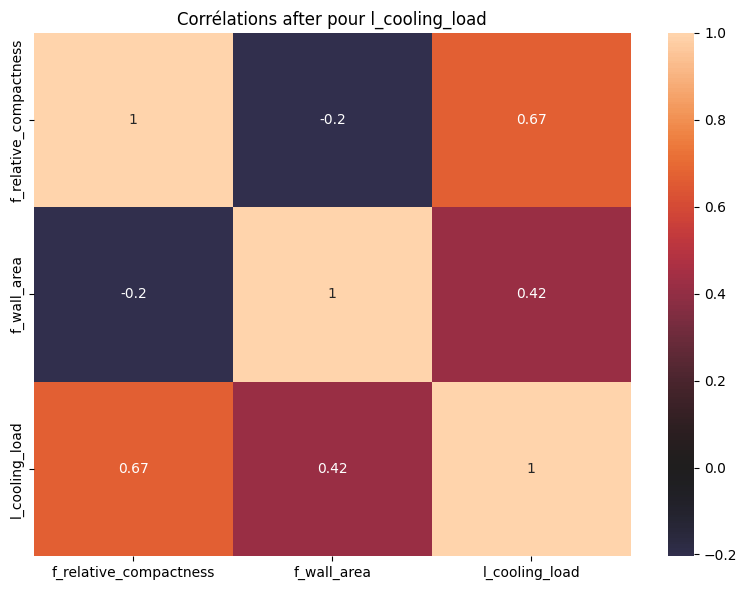


Tableau de synthèse :


Label,Feature,Corr. avant,Transforms
l_heating_load,f_relative_compactness,0.644,"log, sqrt, square"
l_heating_load,f_wall_area,0.448,"log, sqrt, square"
l_cooling_load,f_relative_compactness,0.669,"log, sqrt, square"
l_cooling_load,f_wall_area,0.419,"log, sqrt, square"


In [56]:

def get_polynomial_features(df: pd.DataFrame, target_col: str) -> list:
    """
    Sélectionne les features dont la corrélation absolue avec target_col est
    dans (0.33, 0.66), hors la colonne cible elle-même.
    """
    corrs = df.corr()[target_col].abs()
    feats = corrs[(abs(corrs) > 0.3) & (abs(corrs) < 0.7)].index.tolist()
    return [f for f in feats if f != target_col]

def create_polynomial_features(
    df: pd.DataFrame,
    features: list,
    transformations: list = f_transformations
) -> pd.DataFrame:
    """
    Pour chaque feature, génère des colonnes feat_method selon `transformations`.
    """
    df_poly = df.copy()
    for feat in features:
        x = df[feat].dropna().values
        for method in transformations:
            # autres transformations via apply_transform
            df_poly[f"{feat}_{method}"] = apply_transform(df[feat], method)
    return df_poly

# stockage des résultats
polynomial_analysis_results = {}
normalized_data_pol_sel = {}

print("="*80)
print(f"Création des features polynomiales")
print("="*80)

# on part d'une copie
df_poly = df_transformed.copy()

labels = [c for c in df_transformed.columns if c.startswith('l_') and not(c.endswith("_orig"))]
for label in labels:
    print(f"\nAnalyse pour le label {label} :")
    feats = get_polynomial_features(df_transformed, label)
    if not feats:
        print("Aucune feature sélectionnée pour transformation.")
        continue
    
    print(f"Features sélectionnées : {feats}")
    # création des features
    df_poly = create_polynomial_features(df_poly, feats)
    
    # bilan
    new_cols = [c for c in df_poly.columns if c not in df_transformed.columns]
    print(f"– {len(new_cols)} nouvelles colonnes créées")
    print("Exemple (5 premières) :")
    display(df_poly[new_cols[:5]].head())
    
    # stocker corrélations avant
    corrs_before = {f: data_selected[f].corr(df_transformed[label]) for f in feats}
    polynomial_analysis_results[label] = {
        "features": feats,
        "new_columns": new_cols,
        "correlations_before": corrs_before
    }
    
    # optionnel : afficher rapidement les heatmaps
    for suffix in ["before", "after"]:
        corr_df = (df_transformed if suffix=='before' else df_poly)[feats + [label]].corr()
        plt.figure(figsize=(8,6))
        sns.heatmap(corr_df, annot=True, center=0)
        plt.title(f"Corrélations {suffix} pour {label}")
        plt.tight_layout()
        plt.show()

# synthèse
print("\nTableau de synthèse :")
summary = []
for lbl, info in polynomial_analysis_results.items():
    for feat in info["features"]:
        summary.append({
            "Label": lbl,
            "Feature": feat,
            "Corr. avant": f"{info['correlations_before'][feat]:.3f}",
            "Transforms": ", ".join(f_transformations)
        })

summary_df = pd.DataFrame(summary)
display(
    summary_df.style
        .set_properties(**{"text-align": "left"})
        .set_table_styles([
            {"selector":"th", "props":[("text-align","left")]},
            {"selector":"td", "props":[("text-align","left")]}
        ])
        .hide(axis="index")
)

## 5. Sélection de modèles linéaires optimaux

### Objectif
Pour chaque label (après transformation selon les recommandations de GPT), nous allons déterminer le meilleur modèle linéaire en utilisant trois approches de régression stepwise :

1. **Forward Selection** :
   - Part d'un modèle vide
   - À chaque étape, ajoute la variable qui améliore le plus le modèle
   - S'arrête quand plus aucune variable n'améliore significativement le modèle

2. **Backward Elimination** :
   - Part d'un modèle avec toutes les variables
   - À chaque étape, retire la variable la moins significative
   - S'arrête quand toutes les variables restantes sont significatives

3. **Bidirectional Elimination** (Stepwise) :
   - Combine Forward et Backward
   - À chaque étape, peut soit ajouter soit retirer une variable
   - S'arrête quand plus aucun changement n'améliore le modèle

Pour chaque approche :
- Critère d'entrée : p-value < 0.05
- Critère de sortie : p-value > 0.1
- Métriques d'évaluation : R² ajusté, AIC, BIC
- Validation sur un jeu de test indépendant (30% des données)


In [57]:
from pandas import DataFrame

def calculate_metrics(X, y, X_test=None, y_test=None,
                      y_orig=None, y_test_orig=None,
                      transformation=None):
    """
    OLS + metrics. Si on a X_test,y_test (et y_test_orig),
    calcule aussi train/test R², MSE et RMSE en inversant la transfo.
    Filtre les NaN et gère le cas où il n'y a plus d'observations.
    Conserve également df_train_cmp et df_test_cmp si disponibles.
    """
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()
    metrics = {
        'model':   model,
        'r2_adj':  model.rsquared_adj,
        'aic':     model.aic,
        'bic':     model.bic
    }

    # Initialisation
    metrics['df_train_cmp'] = None
    metrics['df_test_cmp']  = None

    # Train (inverse transform pour MSE/RMSE)
    y_pred_train = model.predict(X_const)
    if y_orig is not None and transformation in l_transformations and transformation != 'none':
        y_pred_train_orig = inverse_transform(y_pred_train, transformation)

        df_train_cmp = pd.DataFrame({'y_true': y_orig, 'y_pred': y_pred_train_orig}).dropna()
        metrics['df_train_cmp'] = df_train_cmp
        if not df_train_cmp.empty:
            train_mse = mean_squared_error(df_train_cmp['y_true'], df_train_cmp['y_pred'])
            metrics['train_mse']  = train_mse
            metrics['train_rmse'] = np.sqrt(train_mse)
        else:
            metrics['train_mse']  = np.nan
            metrics['train_rmse'] = np.nan
    else:
        metrics['train_mse']  = np.nan
        metrics['train_rmse'] = np.nan

    # Test
    if X_test is not None and y_test is not None:
        X_test_const = sm.add_constant(X_test)
        y_pred = model.predict(X_test_const)
        metrics['test_r2'] = r2_score(y_test, y_pred)
        if y_test_orig is not None and transformation in l_transformations and transformation != 'none':
            y_pred_orig = inverse_transform(y_pred, transformation)
            df_test_cmp = pd.DataFrame({'y_true': y_test_orig, 'y_pred': y_pred_orig}).dropna()
            metrics['df_test_cmp'] = df_test_cmp
            if not df_test_cmp.empty:
                test_mse = mean_squared_error(df_test_cmp['y_true'], df_test_cmp['y_pred'])
                metrics['test_mse']  = test_mse
                metrics['test_rmse'] = np.sqrt(test_mse)
            else:
                metrics['test_mse']  = np.nan
                metrics['test_rmse'] = np.nan
        else:
            metrics['test_mse']  = np.nan
            metrics['test_rmse'] = np.nan

    return metrics

def forward_selection(X, y, X_test, y_test,
                      criterion: str = "aic",
                      p_enter: float = 0.05) -> list:
    """
    Sélection vers l'avant en ajoutant à chaque itération la feature qui
    améliore le plus `criterion` sur l'échantillon de test, sous réserve
    que sa p-value < p_enter.
    """
    maximize = criterion not in ("aic", "bic")
    features = list(X.columns)
    selected = []
    while features:
        best_feat, best_val = None, (-np.inf if maximize else np.inf)
        for feat in features:
            mets = calculate_metrics(
                X[selected + [feat]], y,
                X_test[selected + [feat]], y_test
            )
            pval = mets['model'].pvalues.iloc[-1]
            if pval < p_enter:
                val = mets.get(criterion)
                if val is None:
                    raise ValueError(f"Critère inconnu: {criterion}")
                if (maximize and val > best_val) or (not maximize and val < best_val):
                    best_val, best_feat = val, feat
        if best_feat is None:
            break
        selected.append(best_feat)
        features.remove(best_feat)
        print(f"Forward - Ajout de {best_feat} - {criterion} = {best_val:.4f}")

    return selected


def backward_elimination(X, y, X_test, y_test,
                         y_orig=None, y_test_orig=None,
                         transformation=None,
                         criterion: str = "aic",
                         p_remove: float = 0.1) -> list:
    """
    Backward elimination guidée par un critère (test_rmse, aic, etc.)
    en plus de la p-value. La variable retirée est celle avec la plus 
    forte p-value > p_remove qui améliore ou ne dégrade pas trop le critère.
    """
    maximize = criterion not in ("aic", "bic")
    features = list(X.columns)
    best_val = None

    while True:
        mets = calculate_metrics(
            X[features], y,
            X_test[features], y_test,
            y_orig, y_test_orig,
            transformation=transformation
        )
        pvals = mets['model'].pvalues.iloc[1:]  # sans l'intercept
        worst_p = pvals.max()
        worst_feat = pvals.idxmax()

        val = mets.get(criterion)
        if best_val is None:
            best_val = val

        # Arrêt si aucune p-value à éliminer
        if worst_p <= p_remove:
            break

        # Test du modèle sans la variable à forte p-value
        reduced = [f for f in features if f != worst_feat]
        mets_r = calculate_metrics(
            X[reduced], y,
            X_test[reduced], y_test,
            y_orig, y_test_orig,
            transformation=transformation
        )
        new_val = mets_r.get(criterion)

        # Si amélioration ou stabilité du critère, on retire la variable
        if ((maximize and new_val >= best_val) or
            (not maximize and new_val <= best_val)):
            print(f"Backward - Retrait de {worst_feat} - p-val = {worst_p:.4f} - {criterion} = {new_val:.4f}")
            features = reduced
            best_val = new_val
        else:
            break

    return features



def stepwise_selection(X, y, X_test, y_test,
                       criterion: str = "aic",
                       p_enter: float = 0.05,
                       p_remove: float = 0.1) -> list:
    """
    Stepwise : forward + backward, en utilisant `criterion` pour ajouter ou
    retirer une feature selon l'amélioration de ce critère.
    """
    maximize = criterion not in ("aic", "bic")
    selected, available = [], list(X.columns)
    while True:
        changed = False
        # Forward
        best_feat, best_val = None, (-np.inf if maximize else np.inf)
        for feat in available:
            mets = calculate_metrics(
                X[selected + [feat]], y,
                X_test[selected + [feat]], y_test
            )
            pval = mets['model'].pvalues.iloc[-1]
            if pval < p_enter:
                val = mets.get(criterion)
                if (maximize and val > best_val) or (not maximize and val < best_val):
                    best_val, best_feat = val, feat
        if best_feat:
            selected.append(best_feat)
            available.remove(best_feat)
            changed = True
            print(f"Stepwise - Ajout de {best_feat} - {criterion} = {best_val:.4f}")
        # Backward
        if selected:
            mets_full = calculate_metrics(X[selected], y, X_test[selected], y_test)
            pvals = mets_full['model'].pvalues.iloc[1:]
            worst_p = pvals.max()
            if worst_p > p_remove:
                worst_feat = pvals.idxmax()
                selected.remove(worst_feat)
                available.append(worst_feat)
                changed = True
                print(f"Stepwise - Retrait de {worst_feat} - p-val = {worst_p:.4f}")
        if not changed:
            break
    return selected


def validate_models(df: DataFrame,
                    gpt_results: dict,
                    preprocessor=None,
                    test_size: float = 0.3,
                    random_state: int = 42):
    """
    Pipeline de validation :
      - application des transformations (d'après gpt_results)
      - split train/test
      - sélection de features (forward, backward, stepwise)
      - calcul des métriques et choix du meilleur modèle
      - tests de validité (Shapiro, Durbin-Watson, Breusch-Pagan)
    Retourne un dict[file][label] avec les métriques et diagnostics.
    """
    summary = {}
    print(f"\n=== Validation ===")
    # Reconstruction des labels transformés
    df_trans = df.copy()

    for rec in gpt_results:
        lab    = rec['label']
        method = rec['transformation'].lower()
        if method in l_transformations and method != 'none':
            df_trans[lab] = apply_transform(df[f"{lab}_orig"], method)
    # Sélection des features et labels
    features = [c for c in df.columns if c.startswith('f_')]
    labels   = [c for c in df.columns if c.startswith('l_') and not c.endswith('_orig')]
    file_sum = {}

    for lab in labels:
        print(f"\n– Label : {lab}")
        X_raw      = df_trans[features]
        y          = df_trans[lab]
        y_orig     = df[f"{lab}_orig"]

        # split
        X_tr_raw, X_te_raw, y_tr, y_te, y_orig_tr, y_orig_te = \
            train_test_split(X_raw, y, y_orig,
                             test_size=test_size,
                             random_state=random_state)
        # préprocessing si besoin
        if preprocessor:
            X_tr_proc = preprocessor.fit_transform(X_tr_raw)
            X_te_proc = preprocessor.transform(X_te_raw)
            cols = preprocessor.get_feature_names_out()
            X_tr = pd.DataFrame(X_tr_proc, columns=cols, index=X_tr_raw.index)
            X_te = pd.DataFrame(X_te_proc, columns=cols, index=X_te_raw.index)
        else:
            X_tr, X_te = X_tr_raw, X_te_raw

        # Sélection de features pour chaque méthode
        mets_dict = {}
        for name, sel_fn in [
            ('Forward',  forward_selection),
            ('Backward', backward_elimination),
            ('Stepwise', stepwise_selection)
        ]:
            feats = sel_fn(X_tr, y_tr, X_te, y_te)
            mets  = calculate_metrics(
                X_tr[feats], y_tr,
                X_te[feats], y_te,
                y_orig_tr, y_orig_te,
                transformation=next(
                    (r['transformation'].lower() for r in gpt_results if r['label']==lab),
                    None
                )
            )
            mets_dict[name] = {'feats': feats, 'mets': mets}

        # Choix du meilleur modèle sur RMSE test
        best_name, best_feats, best_mets = min(
            ((n, info['feats'], info['mets']) for n, info in mets_dict.items()),
            key=lambda x: x[2].get('test_rmse', np.inf)
        )
        print(f"Meilleur : {best_name} → RMSE test = {best_mets['test_rmse']:.4f}")

        # Diagnostics
        model = best_mets['model']
        resid = model.resid
        sw_s, sw_p = shapiro(resid)
        dw         = durbin_watson(resid)
        bp_p       = het_breuschpagan(resid, model.model.exog)[1]
        print(f" Shapiro p={sw_p:.3f} → {'OK' if sw_p>0.05 else 'Alerte'}")
        print(f" Durbin-Watson={dw:.3f} → {'OK' if 1.5<dw<2.5 else 'Alerte'}")
        print(f" Breusch-Pagan p={bp_p:.3f} → {'OK' if bp_p>0.05 else 'Alerte'}")

        # Résumé
        file_sum[lab] = {
            'best_method':    best_name,
            'best_features':  best_feats,
            'r2_test':        best_mets['test_r2'],
            'mse_train':      best_mets.get('train_mse', np.nan),
            'rmse_train':     best_mets.get('train_rmse', np.nan),
            'mse_test':       best_mets.get('test_mse', np.nan),
            'rmse_test':      best_mets.get('test_rmse', np.nan),
            'aic':            best_mets['aic'],
            'bic':            best_mets['bic'],
            'shapiro_p':      sw_p,
            'durbin_watson':  dw,
            'breusch_pagan_p':bp_p
        }

    return file_sum


In [58]:
df_poly.head()

,f_relative_compactness,f_wall_area,f_overall_height,f_orientation,f_glazing_area,l_heating_load,l_cooling_load,l_heating_load_orig,l_cooling_load_orig,f_relative_compactness_log,f_relative_compactness_sqrt,f_relative_compactness_square,f_wall_area_log,f_wall_area_sqrt,f_wall_area_square
0,0.98,294.0,7.0,2,0.0,2.744061,3.060115,15.55,21.33,-0.020203,0.989949,0.9604,5.683580,17.146428,86436.00
1,0.98,294.0,7.0,3,0.0,2.744061,3.060115,15.55,21.33,-0.020203,0.989949,0.9604,5.683580,17.146428,86436.00
2,0.98,294.0,7.0,4,0.0,2.744061,3.060115,15.55,21.33,-0.020203,0.989949,0.9604,5.683580,17.146428,86436.00
3,0.98,294.0,7.0,5,0.0,2.744061,3.060115,15.55,21.33,-0.020203,0.989949,0.9604,5.683580,17.146428,86436.00
4,0.90,318.5,7.0,2,0.0,3.036874,3.342155,20.84,28.28,-0.105361,0.948683,0.8100,5.763622,17.846568,101442.25


In [59]:

# -------------------------------------------------------------------
# 1) Validation avec centrage–réduction
# -------------------------------------------------------------------
print(f"\n=== Validation centrée–réduite ===")
# Sélection des colonnes
features = [c for c in df_poly.columns if c.startswith("f_")]
numeric_features = [f for f in features if pd.api.types.is_numeric_dtype(df_poly[f])]
categorical_features = [f for f in features if isinstance(df_poly[f].dtype, CategoricalDtype)]
# Préprocesseur
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
], remainder="drop")
# Appel à validate_models 
sub = validate_models(
    df_poly,
    gpt_results,
    preprocessor=preprocessor,
    test_size=0.3,
    random_state=42
)

# -------------------------------------------------------------------
# 2) Reconstruction de best_features_scaled
# -------------------------------------------------------------------
best_features_scaled={}
for label, m in sub.items():
    best_features_scaled[label] = m["best_features"]

# -------------------------------------------------------------------
# 3) Tests de validité (Shapiro, Durbin–Watson, Breusch–Pagan)
# -------------------------------------------------------------------
print("\n=== Tests de validité (features centrées–réduites) ===")
for label, m in sub.items():
    sw_p = m["shapiro_p"]
    dw   = m["durbin_watson"]
    bp_p = m["breusch_pagan_p"]
    print(f"Label {label}:")
    print(f"  Shapiro-Wilk p = {sw_p:.3f} → {'OK' if sw_p>0.05 else 'Alerte'}")
    print(f"  Durbin-Watson  = {dw:.3f} → {'OK' if 1.5<dw<2.5 else 'Alerte'}")
    print(f"  Breusch-Pagan  p = {bp_p:.3f} → {'OK' if bp_p>0.05 else 'Alerte'}")

# -------------------------------------------------------------------
# 4) Construction du DataFrame récapitulatif
# -------------------------------------------------------------------
rows = []
for label, m in sub.items():
    rows.append({
        "Label":       label,
        "Méthode":     m["best_method"],
        "Nb features": len(m["best_features"]),
        "MSE train":   m.get("mse_train",   np.nan),
        "RMSE train":  m.get("rmse_train",  np.nan),
        "MSE test":    m.get("mse_test",    np.nan),
        "RMSE test":   m.get("rmse_test",   np.nan),
        "AIC":         m["aic"],
        "BIC":         m["bic"]
    })
summary_df_scaled = pd.DataFrame(rows)

# -------------------------------------------------------------------
# 5) Style du tableau sans warnings
# -------------------------------------------------------------------
mse_cols    = [c for c in ["MSE train","MSE test"]  if c in summary_df_scaled and summary_df_scaled[c].notna().any()]
rmse_cols   = [c for c in ["RMSE train","RMSE test"] if c in summary_df_scaled and summary_df_scaled[c].notna().any()]
aicbic_cols = [c for c in ["AIC","BIC"]             if c in summary_df_scaled and summary_df_scaled[c].notna().any()]

styled_scaled = (
    summary_df_scaled
    .set_index(["Label"])
    .style
    .format({
        "Nb features": "{:d}",
        **{c: "{:.3f}" for c in mse_cols + rmse_cols},
        **{c: "{:.2f}" for c in aicbic_cols}
    })
)

if mse_cols:
    styled_scaled = styled_scaled.bar(subset=mse_cols, align="mid", color="#8ecae6")
if rmse_cols:
    styled_scaled = styled_scaled.bar(subset=rmse_cols, align="mid", color="#219ebc")
if aicbic_cols:
    styled_scaled = styled_scaled.background_gradient(subset=aicbic_cols, cmap="Blues_r")

styled_scaled = styled_scaled.set_table_styles([
    {"selector":"th", "props":[
        ("background-color","#023047"), ("color","white"),
        ("font-weight","bold"), ("text-align","center"),
        ("padding","8px")
    ]},
    {"selector":"td", "props":[
        ("padding","6px"), ("text-align","center")
    ]},
    {"selector":"tr:nth-child(even)", "props":[
        ("background-color","#f0f0f0")
    ]}
]).set_caption("Synthèse centrée–réduite des métriques des modèles")

display(styled_scaled)


=== Validation centrée–réduite ===

=== Validation ===

– Label : l_heating_load
Forward - Ajout de num__f_overall_height - aic = -160.7409
Forward - Ajout de num__f_glazing_area - aic = -480.2525
Forward - Ajout de num__f_wall_area_log - aic = -737.8879
Backward - Retrait de cat__f_orientation_5 - p-val = 0.8325 - aic = -1092.9850
Backward - Retrait de cat__f_orientation_4 - p-val = 0.5537 - aic = -1094.6253
Backward - Retrait de cat__f_orientation_3 - p-val = 0.6429 - aic = -1096.4052
Stepwise - Ajout de num__f_overall_height - aic = -160.7409
Stepwise - Ajout de num__f_glazing_area - aic = -480.2525
Stepwise - Ajout de num__f_wall_area_log - aic = -737.8879
Meilleur : Backward → RMSE test = 1.6182
 Shapiro p=0.000 → Alerte
 Durbin-Watson=2.033 → OK
 Breusch-Pagan p=0.000 → Alerte

– Label : l_cooling_load
Forward - Ajout de num__f_overall_height - aic = -476.2871
Forward - Ajout de num__f_glazing_area - aic = -665.0461
Forward - Ajout de num__f_wall_area_log - aic = -811.8004
Forwa

,Méthode,Nb features,MSE train,RMSE train,MSE test,RMSE test,AIC,BIC
Label,,,,,,,,
l_heating_load,Backward,10,2.344,1.531,2.619,1.618,-1096.41,-1049.26
l_cooling_load,Forward,12,3.264,1.807,3.712,1.927,-1368.19,-1312.47


## 6. Modélisation WLS et comparaison OLS vs WLS
# Présentation de la démarche de modélisation linéaire et WLS

Ce notebook vise à construire et comparer deux approches de régression linéaire — OLS (Ordinary Least Squares) et WLS (Weighted Least Squares) — pour prédire les charges de chauffage et de climatisation à partir de caractéristiques architecturales.

## 1. OLS et WLS : définitions et intérêts
- **OLS (régression aux moindres carrés ordinaires)** cherche à minimiser la somme des carrés des résidus (erreurs). C’est le point de départ classique, simple à interpréter.
- **WLS (régression aux moindres carrés pondérés)** ajoute un poids à chaque observation, inversement proportionnel à une estimation de sa variance. Elle corrige l’hétéroscédasticité (variance non constante des résidus) et renforce la robustesse lorsque certaines observations sont plus bruyantes.

> *Pourquoi comparer ?*  
> • Vérifier si la prise en compte de poids améliore la qualité prédictive (RMSE) et la validité des hypothèses (normalité, homoscédasticité).  
> • Choisir le modèle le plus adapté aux données réelles où la variance des erreurs peut varier.

## 2. Structure générale de la procédure
1. **Préparation des données** : aplica­tion de transformations (log, racine…) pour garantir la linéarité et la normalité des distributions.
2. **Sélection de variables** : identification rigoureuse de features numériques et catégorielles, gestion de la multicolinéarité et des redondances.
3. **Enrichissement** : ajout de termes polynomiaux significatifs pour capturer les non‑linéarités.
4. **Standardisation** : encodage one‑hot des catégorielles et centrage‑réduction, pour rendre les coefficients directement comparables.
5. **Ajustement OLS** : estimation initiale et calcul des résidus au carré.
6. **Estimation de la variance des résidus** : modélisation par OLS des résidus² pour en déduire des poids.
7. **Ajustement WLS** : réajustement des coefficients avec les poids inverses de la variance.
8. **Évaluation** : comparaison des RMSE sur données transformées et d’origine, pour OLS et WLS.
9. **Tests de validité** : Shapiro–Wilk (normalité), Durbin–Watson (indépendance), Breusch–Pagan (homoscedasticité) sur résidus train/test.
10. **Traitement des outliers** : détection par résidus studentized et correction de Bonferroni, exclusion des points aberrants et réentraînement.
11. **Diagnostics finaux** : vérification des hypothèses sur le modèle sans outliers et inspection des QQ‑plots.

---

Cette démarche intégrée garantit un pipeline statistiquement rigoureux, permettant de sélectionner automatiquement le modèle (OLS ou WLS) le plus adapté, tout en maîtrisant la complexité, la qualité de l’ajustement et la validité des hypothèses sous‑jacentes.

### 6.1 Boucle principale WLS et OLS par label

In [60]:
wls_results = {}

for label, feats in best_features_scaled.items():
    print("\n" + "="*80)
    print(f"WLS pour {label}")
    print("="*80)

    # 1) Récupérer la transformation recommandée
    trafo = next(
        (r["transformation"].lower()
         for r in gpt_results
         if r["label"] == label),
        "none"
    )
    # 2) Construire y via la transformation sur données originales
    y = apply_transform(df_poly[f"{label}_orig"], trafo)

    # 3) Prétraitement : StandardScaler + OneHotEncoder
    all_feats = [c for c in df_poly.columns if c.startswith("f_")]
    numeric = [c for c in all_feats if pd.api.types.is_numeric_dtype(df_poly[c])]
    categorical = [
        c for c in all_feats
        if isinstance(df_poly[c].dtype, pd.CategoricalDtype)
    ]

    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical)
    ], remainder="drop")

    X_full = df_poly[numeric + categorical]
    X_proc = preprocessor.fit_transform(X_full)
    cols   = preprocessor.get_feature_names_out()
    X_all  = pd.DataFrame(X_proc, columns=cols, index=df_poly.index)

    # 4) Sélectionner les colonnes finales
    X = X_all[feats]

    # 5) Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # 6) OLS pour estimer variance résidus
    ols = sm.OLS(y_train, sm.add_constant(X_train)).fit()
    resid2 = ols.resid ** 2

    # 7) Modèle de variance conditionnelle et poids WLS
    var_mod = sm.OLS(resid2, sm.add_constant(X_train)).fit()
    fitted_var = var_mod.predict(sm.add_constant(X_train))
    min_pos = np.min(fitted_var[fitted_var > 0])
    fitted_var = np.where(fitted_var <= 0, min_pos, fitted_var)

    # 8) Ajuster WLS
    wls = sm.WLS(y_train, sm.add_constant(X_train), weights=1/fitted_var).fit()

    # 9) Évaluation RMSE sur échelle transformée
    y_pred_ols = ols.predict(sm.add_constant(X_test))
    y_pred_wls = wls.predict(sm.add_constant(X_test))
    rmse_ols   = np.sqrt(mean_squared_error(y_test, y_pred_ols))
    rmse_wls   = np.sqrt(mean_squared_error(y_test, y_pred_wls))
    
    # 10) RMSE sur échelle d'origine
    y_test_orig = df_poly[f"{label}_orig"].loc[X_test.index]
    # Appliquer la transformation inverse aux prédictions
    if trafo != "none":
        y_pred_ols_orig = inverse_transform(y_pred_ols, trafo)
        y_pred_wls_orig = inverse_transform(y_pred_wls, trafo)
    else:
        y_pred_ols_orig = y_pred_ols
        y_pred_wls_orig = y_pred_wls
    rmse_ols_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_ols_orig))
    rmse_wls_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_wls_orig))    

    # 11) Affichage comparatif
    print("OLS :")
    print(f"  R² adj (train): {ols.rsquared_adj:.4f}")
    print(f"  RMSE (test):   {rmse_ols_orig:.4f}")
    print("WLS :")
    print(f"  R² adj (train): {wls.rsquared_adj:.4f}")
    print(f"  RMSE (test transformé): {rmse_wls_orig:.4f}")
    print("\nRésumé WLS :")
    print(wls.summary())

    # 12) Tests de normalité (Shapiro-Wilk) résidus train/test
    def shapiro_p(arr):
        return stats.shapiro(arr)[1]

    p_ols_tr = shapiro_p(ols.resid)
    p_wls_tr = shapiro_p(wls.resid)
    p_ols_te = shapiro_p(y_test - y_pred_ols)
    p_wls_te = shapiro_p(y_test - y_pred_wls)

    print("\nShapiro-Wilk (p-value) :")
    print(f" - OLS train : {p_ols_tr:.4f}")
    print(f" - WLS train : {p_wls_tr:.4f}")
    print(f" - OLS test  : {p_ols_te:.4f}")
    print(f" - WLS test  : {p_wls_te:.4f}")

    # 13) Stockage des résultats
    wls_results[label] = {
        'ols_model':  ols,
        'wls_model':  wls,
        'rmse_ols':   rmse_ols_orig,
        'rmse_wls':   rmse_wls_orig,
        'p_shapiro': {
            'ols_train': p_ols_tr,
            'wls_train': p_wls_tr,
            'ols_test':  p_ols_te,
            'wls_test':  p_wls_te
        }
    }


WLS pour l_heating_load
OLS :
  R² adj (train): 0.9668
  RMSE (test):   1.6182
WLS :
  R² adj (train): 0.9854
  RMSE (test transformé): 1.5205

Résumé WLS :
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.986
Model:                            WLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     3613.
Date:                Sun, 08 Jun 2025   Prob (F-statistic):               0.00
Time:                        23:54:00   Log-Likelihood:                 713.50
No. Observations:                 537   AIC:                            -1405.
Df Residuals:                     526   BIC:                            -1358.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                         coef    std

### 6.2 Interprétation automatique OLS vs WLS

In [61]:
print("\n=== Interprétation des modèles OLS vs WLS ===")
for label, res in wls_results.items():
    print("\n" + "-"*80)
    print(f"Analyse pour {label}")
    print("-"*80)
    
    ols_rmse = res['rmse_ols']
    wls_rmse = res['rmse_wls']
    rmse_diff = ols_rmse - wls_rmse

    # 1) Performance comparée
    if rmse_diff > 0:
        print(f"• Performance : WLS améliore la prédiction "
              f"(RMSE OLS={ols_rmse:.3f} vs WLS={wls_rmse:.3f}, gain de {rmse_diff:.3f}).")
    elif rmse_diff < 0:
        print(f"• Performance : OLS était légèrement meilleur "
              f"(RMSE OLS={ols_rmse:.3f} vs WLS={wls_rmse:.3f}, perte de {(-rmse_diff):.3f}).")
    else:
        print(f"• Performance : RMSE identique pour OLS et WLS ({ols_rmse:.3f}).")

    # 2) Normalité des résidus (Shapiro–Wilk)
    p = res['p_shapiro']
    for stage in ['ols_train','wls_train','ols_test','wls_test']:
        val = p[stage]
        tag = "OK" if val > 0.05 else "Alerte"
        context = "entraînement" if "train" in stage else "test"
        model = "OLS" if stage.startswith("ols") else "WLS"
        print(f"• Normalité ({model}, {context}) : p = {val:.3f} → {tag}.")

    # 3) Choix final : on force WLS si WLS corrige la normalité quand OLS échoue,
    #    même si RMSE est légèrement plus élevé.
    if p['wls_train'] > 0.05 and p['ols_train'] <= 0.05:
        best = 'wls'
        print("• Choix du modèle : WLS retenu car il passe la normalité d’entraînement là où OLS échoue.")
    elif rmse_diff > 0:
        best = 'wls'
        print("• Choix du modèle : WLS retenu pour son meilleur RMSE.")
    else:
        best = 'ols'
        print("• Choix du modèle : OLS retenu.")

    # 4) Diagnostics d’autocorrélation et d’homoscédasticité sur le modèle retenu
    model_obj = res[f'{best}_model']
    resid_best = model_obj.resid

    dw_stat = durbin_watson(resid_best)
    bp_p    = het_breuschpagan(resid_best, model_obj.model.exog)[1]

    dw_msg = "OK : pas d’autocorrélation (1.5 < DW < 2.5)" if 1.5 < dw_stat < 2.5 else "Alerte : autocorrélation possible"
    bp_msg = "OK : homoscédasticité (p > 0.05)" if bp_p > 0.05 else "Alerte : hétéroscédasticité détectée"

    print(f"• Diagnostics sur {best.upper()} :")
    print(f"    - Durbin–Watson           = {dw_stat:.3f} → {dw_msg}")
    print(f"    - Breusch–Pagan (p-value) = {bp_p:.3f} → {bp_msg}")


=== Interprétation des modèles OLS vs WLS ===

--------------------------------------------------------------------------------
Analyse pour l_heating_load
--------------------------------------------------------------------------------
• Performance : WLS améliore la prédiction (RMSE OLS=1.618 vs WLS=1.520, gain de 0.098).
• Normalité (OLS, entraînement) : p = 0.000 → Alerte.
• Normalité (WLS, entraînement) : p = 0.000 → Alerte.
• Normalité (OLS, test) : p = 0.000 → Alerte.
• Normalité (WLS, test) : p = 0.000 → Alerte.
• Choix du modèle : WLS retenu pour son meilleur RMSE.
• Diagnostics sur WLS :
    - Durbin–Watson           = 1.989 → OK : pas d’autocorrélation (1.5 < DW < 2.5)
    - Breusch–Pagan (p-value) = 0.000 → Alerte : hétéroscédasticité détectée

--------------------------------------------------------------------------------
Analyse pour l_cooling_load
--------------------------------------------------------------------------------
• Performance : OLS était légèrement meill

### 6.3 Nettoyage des outliers

In [62]:
model_results = {}
best_features_dict_wo_outliers={}
for label, result in sub.items():                     # <<< MODIF: on récupère result contenant best_method et best_features
    model_choice = result['best_method']     # 'ols' ou 'wls'             # <<< MODIF: utilisation du modèle sélectionné
    feats        = result['best_features']   # liste de features              # <<< MODIF: utilisation des bonnes features

    print("" + "="*80)
    print(f"Nettoyage des outliers pour '{label}' (méthode = {model_choice.upper()})")
    print("="*80)

    # 1) Charger la transformation
    trafo = next(r["transformation"].lower()
                 for r in gpt_results if r["label"] == label)

    # 2) Construire y_trf et garder y_orig
    y_orig = df_poly[f"{label}_orig"]
    y_trf = apply_transform(y_orig, trafo)
    y = pd.Series(y_trf, index=df_poly.index, name=label)

    # 3) Préparer X (scaling + one-hot) et sélectionner feats
    all_feats   = [c for c in df_poly.columns if c.startswith("f_")]
    numeric     = [c for c in all_feats if pd.api.types.is_numeric_dtype(df_poly[c])]
    categorical = [c for c in all_feats if isinstance(df_poly[c].dtype, pd.CategoricalDtype)]
    preproc = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical)
    ], remainder="drop")
    X_full = df_poly[numeric + categorical]
    X_proc = preproc.fit_transform(X_full)
    cols   = preproc.get_feature_names_out()
    X_all  = pd.DataFrame(X_proc, columns=cols, index=df_poly.index)
    X      = X_all[feats]

    # 4) Split train/test incluant y_orig
    X_tr, X_te, y_tr, y_te, y_orig_tr, y_orig_te = train_test_split(
        X, y, y_orig, test_size=0.3, random_state=42
    )

    # 5) Ajuster le modèle initial selon model_choice
    if model_choice == "ols":
        base_mod = OLS(y_tr, add_constant(X_tr)).fit()
    else:  # wls
        tmp    = OLS(y_tr, add_constant(X_tr)).fit()
        var2   = tmp.resid**2
        varmod = OLS(var2, add_constant(X_tr)).fit()
        fv     = varmod.predict(add_constant(X_tr))
        minpos = np.min(fv[fv > 0])
        w      = np.where(fv <= 0, minpos, fv)
        base_mod = WLS(y_tr, add_constant(X_tr), weights=1/w).fit()

    # 6) Détection d'outliers (test de Bonferroni)
    if model_choice == "ols":
        p_bonf = outlier_test(base_mod)["bonf(p)"]
    else:
        infl   = OLSInfluence(base_mod)
        ext    = infl.resid_studentized_external
        df_res = int(base_mod.df_resid)
        p_raw  = 2 * (1 - t.cdf(np.abs(ext), df_res))
        p_bonf = pd.Series(np.minimum(p_raw * len(ext), 1.0),
                           index=base_mod.model.data.row_labels,
                           name="bonf(p)")
    mask = p_bonf >= 0.05
    keep = mask[mask].index
    n_out = len(mask) - len(keep)
    print(f"Nombre d'outliers détectés ({model_choice.upper()}): {n_out}")

    # 7) Réentraînement si nécessaire
    if n_out > 0:
        X_tr = X_tr.loc[keep]
        y_tr = y_tr.loc[keep]
        if model_choice == "ols":
            final_mod = OLS(y_tr, add_constant(X_tr)).fit()
        else:
            tmp    = OLS(y_tr, add_constant(X_tr)).fit()
            var2   = tmp.resid**2
            varmod = OLS(var2, add_constant(X_tr)).fit()
            fv     = varmod.predict(add_constant(X_tr))
            minpos = np.min(fv[fv > 0])
            w      = np.where(fv <= 0, minpos, fv)
            final_mod = WLS(y_tr, add_constant(X_tr), weights=1/w).fit()
        print(final_mod.summary())
    else:
        final_mod = base_mod

    # 8) Calcul des métriques sur échelle d'origine
    if n_out > 0:
        y_orig_tr = y_orig_tr.loc[y_tr.index]
    mets = calculate_metrics(
        X_tr, y_tr,
        X_test      = X_te,
        y_test      = y_te,
        y_orig      = y_orig_tr,
        y_test_orig = y_orig_te,
        transformation = trafo
    )
    # 8bis) Calcul du RMSE sur l’échelle transformée
    # -----------------------------------------------
    # Prédictions sur train et test (échelle transformée)
    y_pred_tr = final_mod.predict(add_constant(X_tr))
    y_pred_te = final_mod.predict(add_constant(X_te))
    rmse_tr_train = np.sqrt(mean_squared_error(y_tr, y_pred_tr))
    rmse_tr_test  = np.sqrt(mean_squared_error(y_test, y_pred_te))
    print(f"RMSE transformé – train : {rmse_tr_train:.4f}, test : {rmse_tr_test:.4f}")

    # 8ter) Calcul du RMSE sur l’échelle d’origine
    # --------------------------------------------
    # On reconvertit les prédictions, si nécessaire
    if trafo != "none":
        y_pred_tr_orig = inverse_transform(y_pred_tr, trafo)
        y_pred_te_orig = inverse_transform(y_pred_te, trafo)
    else:
        y_pred_tr_orig = y_pred_tr
        y_pred_te_orig = y_pred_te

    # On récupère les vraies valeurs d’origine
    y_orig_tr_aligned = y_orig_tr.loc[X_tr.index]
    y_orig_te_aligned = y_orig_te.loc[X_te.index]

    rmse_orig_train = np.sqrt(mean_squared_error(y_orig_tr_aligned, y_pred_tr_orig))
    rmse_orig_test  = np.sqrt(mean_squared_error(y_orig_te_aligned, y_pred_te_orig))
    print(f"RMSE origine – train : {rmse_orig_train:.4f}, test : {rmse_orig_test:.4f}")

    # 9) Test de normalité des résidus originaux
    y_pred_tr = final_mod.predict(add_constant(X_tr))
    if trafo != "none":
        y_pred_tr_orig = inverse_transform(y_pred_tr, trafo)
    else:
        y_pred_tr_orig = y_pred_tr
    y_pred_tr_orig = pd.Series(y_pred_tr_orig, index=X_tr.index)
    resid_orig     = (y_orig_tr - y_pred_tr_orig).dropna()
    sw_stat, sw_p  = shapiro(resid_orig)

    best_features_dict_wo_outliers[label] = {
        "model":          final_mod,
        "features":       feats,          
        "transformation": trafo,
        "metrics":        mets,
        "resid_orig":     resid_orig,
        "shapiro_p":      sw_p,
        "exog_orig":      add_constant(X_tr)
    }


Nettoyage des outliers pour 'l_heating_load' (méthode = BACKWARD)
Nombre d'outliers détectés (BACKWARD): 10
                            WLS Regression Results                            
Dep. Variable:         l_heating_load   R-squared:                       0.997
Model:                            WLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 1.548e+04
Date:                Sun, 08 Jun 2025   Prob (F-statistic):               0.00
Time:                        23:54:00   Log-Likelihood:                 773.76
No. Observations:                 527   AIC:                            -1526.
Df Residuals:                     516   BIC:                            -1479.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]

### 6.4 Diagnostics finaux

=== Diagnostics sur les modèles sans outliers ===

l_heating_load
>>> Diagnostics en espace transformé <<<
1) Shapiro–Wilk    : p = 0.000 → Alerte : résidus transformés non normaux
2) Durbin–Watson   : stat = 1.930 → OK : pas d’autocorrélation (1.5 < DW < 2.5)
3) Breusch–Pagan   : p = 0.000 → Alerte : hétéroscédasticité détectée


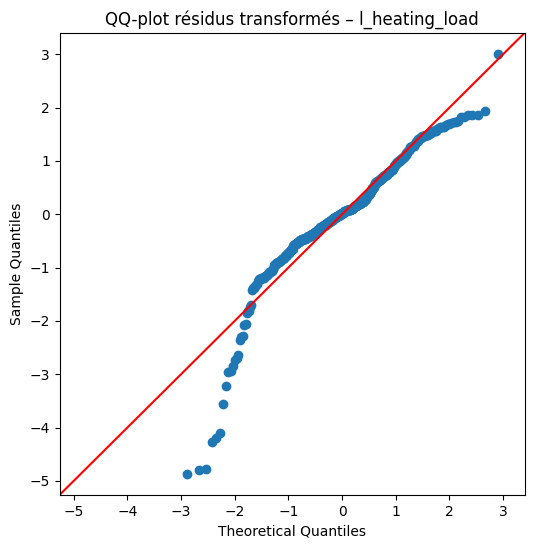


l_cooling_load
>>> Diagnostics en espace transformé <<<
1) Shapiro–Wilk    : p = 0.122 → OK : résidus transformés normaux (p > 0.05)
2) Durbin–Watson   : stat = 1.940 → OK : pas d’autocorrélation (1.5 < DW < 2.5)
3) Breusch–Pagan   : p = 0.000 → Alerte : hétéroscédasticité détectée


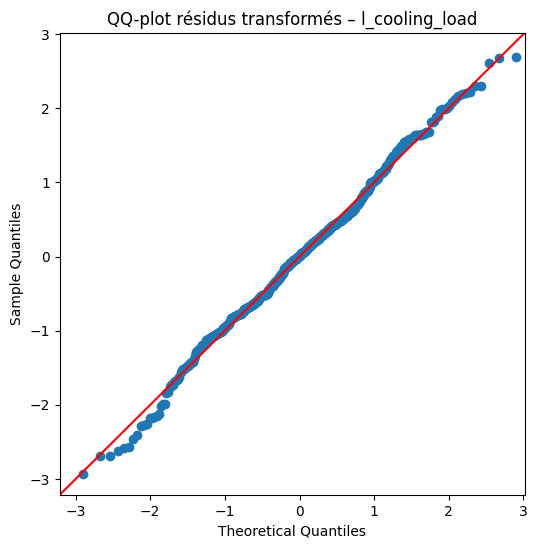

In [63]:
# Diagnostics finaux sur modèles après suppression des outliers
print("=== Diagnostics sur les modèles sans outliers ===")

for label, info in best_features_dict_wo_outliers.items():
    print("\n" + "="*80)
    print(f"{label}")
    print("="*80)

    model = info['model']                  # OLS ou WLS sélectionné après outliers
    # 1) Résidus et exogènes en espace transformé
    resid_trf = model.resid               # MODIF: on prend les résidus du modèle final
    exog_trf  = model.model.exog          # MODIF: on prend les exogènes du modèle final

    # 2) Shapiro–Wilk (normalité)
    sw_stat, sw_p = shapiro(resid_trf)
    sw_msg = "OK : résidus transformés normaux (p > 0.05)" if sw_p > 0.05 else "Alerte : résidus transformés non normaux"

    # 3) Durbin–Watson (autocorrélation)
    dw = durbin_watson(resid_trf)
    dw_msg = "OK : pas d’autocorrélation (1.5 < DW < 2.5)" if 1.5 < dw < 2.5 else "Alerte : autocorrélation possible"

    # 4) Breusch–Pagan (hétéroscédasticité)
    _, bp_p, _, _ = het_breuschpagan(resid_trf, exog_trf)
    bp_msg = "OK : homoscédasticité (p > 0.05)" if bp_p > 0.05 else "Alerte : hétéroscédasticité détectée"

    # Affichage diagnostics transformés
    print(">>> Diagnostics en espace transformé <<<")
    print(f"1) Shapiro–Wilk    : p = {sw_p:.3f} → {sw_msg}")
    print(f"2) Durbin–Watson   : stat = {dw:.3f} → {dw_msg}")
    print(f"3) Breusch–Pagan   : p = {bp_p:.3f} → {bp_msg}")

    # 5) QQ-plot résidus transformés
    fig, ax = plt.subplots(figsize=(6,6))
    sm.qqplot(resid_trf, line='45', fit=True, ax=ax)
    ax.set_title(f"QQ-plot résidus transformés – {label}")
    plt.show()